In [1]:
import numpy as np
from numba import njit , prange
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from joblib import Parallel, delayed
from scipy.stats import skew
from scipy.ndimage import uniform_filter1d
from scipy.signal import hilbert
import pandas as pd
from tqdm import tqdm
import progressbar 
import os, json, time, gc, io, contextlib, math
from numba import set_num_threads, get_num_threads
from operator import mod
from itertools import product
from statsmodels.tsa.stattools import adfuller
from itertools import permutations
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm

ಠ_ಠ = "hmmm..."


def get_fields(df, fields, Nn, Nb, Nd):
    processed_fields = []
    for label, column_name in fields:
        arr = df[column_name].values.reshape(Nn, Nb, Nd)
        processed_fields.append((label, arr))
    return processed_fields

def truncate_colormap(cmap_name, min_val=0.0, max_val=1.0, n=256, reverse=False):
    cmap = plt.get_cmap(cmap_name)
    new_colors = cmap(np.linspace(min_val, max_val, n))
    if reverse:
        new_colors = new_colors[::-1]
    return mcolors.LinearSegmentedColormap.from_list(
        f"trunc_{cmap_name}_{min_val}_{max_val}",
        new_colors
    )

def plot_NxM(b_rate_list, d_rate_list, n_individuals_list, costume_name, filenamefields, fields, selected_n_values, cmap, figsize=(14, 12), dpi=600, rowssharecolorbar=True, pltshow = True, figtitle = 0 ):
    for n_val in selected_n_values:
        if n_val not in n_individuals_list:
            raise ValueError(f"n={n_val} not found in n_individuals_list")    
    Nrows = len(fields)
    Ncols = len(selected_n_values)
    fig, axes = plt.subplots(Nrows, Ncols, figsize=figsize, sharex=True, sharey=True, constrained_layout=True)
    if figtitle != 0 : fig.suptitle(figtitle, fontsize=16) # Main title
    # fig.subplots_adjust(wspace=0.12, hspace=0.12, right=0.88)  # leave space for colorbars at right
    dx = d_rate_list[1] - d_rate_list[0]
    dy = b_rate_list[1] - b_rate_list[0]
    extent = [d_rate_list[0]-dx/2, d_rate_list[-1]+dx/2, b_rate_list[0]-dy/2, b_rate_list[-1]+dy/2]

    for row, (label, arr) in enumerate(fields):
        slices = []
        for col, n_val in enumerate(selected_n_values):
            i = np.where(n_individuals_list == n_val)[0][0]
            slices.append(arr[i])
        masked_slices = []
        for s in slices:
            s2 = s.copy()
            s2[0, 0] = np.nan   # ignore element [0,0] in each slice
            masked_slices.append(s2)
        stacked = np.stack(masked_slices)
        row_min = np.nanmin(stacked)
        row_max = np.nanmax(stacked)


        norm = None
        for col, n_val in enumerate(selected_n_values):
            i = np.where(n_individuals_list == n_val)[0][0]            
            ax = axes[row, col]
            Z = arr[i]
            Z[0,0] = np.nan
            if rowssharecolorbar==True: im = ax.imshow(Z, origin="lower", extent=extent, aspect="equal", cmap=cmap, vmin=row_min, vmax=row_max)  # interpolation="nearest"  aspect="auto"
            else: im = ax.imshow(Z, origin="lower", extent=extent, aspect="equal", cmap=cmap)  # interpolation="nearest"

            if col == 0: 
                if row == Nrows//2: ax.set_ylabel(f"{label}\n\n Slope of birth rate", fontsize=12, labelpad=-0.01)
                else: ax.set_ylabel(f"{label}\n\n    ", fontsize=12, labelpad=-0.01)
                ax.set_yticks(b_rate_list[::8] )
                ax.set_yticklabels([f"{b:.1f}" for b in b_rate_list[::8] ], fontsize=10)

            if row == Nrows-1: 
                if col == Ncols//2: ax.set_xlabel("Slope of death rate", fontsize=12)
                # ax.set_xticks(ax.get_yticks(), rotation=90)
                ax.set_xticks(d_rate_list[::8] )
                ax.set_xticklabels([f"{d:.1f}" for d in d_rate_list[::8] ], fontsize=10, rotation=90)


            if row == 0: ax.set_title(fr"$N = {n_val}$", fontsize=13)
            if col == Ncols-1 and rowssharecolorbar==True: fig.colorbar(im, ax=ax)
            elif rowssharecolorbar==False: fig.colorbar(im, ax=ax)

    field_names = costume_name + "_".join(filenamefields)
    nvals_str = "_".join(str(n) for n in selected_n_values)
    filename = os.path.join("plot3x3", f"{field_names}_n_{nvals_str}.png")

    # filename = f"plot3x3/{field_names}_n_{nvals_str}.png"
    plt.savefig(filename, dpi=dpi, bbox_inches="tight")
    if pltshow == True: plt.show()
    else: plt.close()



def plot_NxM(b_rate_list, d_rate_list, n_individuals_list, costume_name, filenamefields, fields, selected_n_values, cmap, figsize=(14, 12), dpi=600, rowssharecolorbar=True, pltshow = True, figtitle = 0 ):
    for n_val in selected_n_values:
        if n_val not in n_individuals_list:
            raise ValueError(f"n={n_val} not found in n_individuals_list")    
    Nrows = len(fields)
    Ncols = len(selected_n_values)
    fig, axes = plt.subplots(Nrows, Ncols, figsize=figsize, sharex=True, sharey=True, constrained_layout=True)
    if figtitle != 0 : fig.suptitle(figtitle, fontsize=16) # Main title
    # fig.subplots_adjust(wspace=0.12, hspace=0.12, right=0.88)  # leave space for colorbars at right
    dx = d_rate_list[1] - d_rate_list[0]
    dy = b_rate_list[1] - b_rate_list[0]
    extent = [d_rate_list[0]-dx/2, d_rate_list[-1]+dx/2, b_rate_list[0]-dy/2, b_rate_list[-1]+dy/2]

    for row, (label, arr) in enumerate(fields):
        slices = []
        for col, n_val in enumerate(selected_n_values):
            i = np.where(n_individuals_list == n_val)[0][0]
            slices.append(arr[i])
        masked_slices = []
        for s in slices:
            s2 = s.copy()
            #s2[0, 0] = np.nan   # ignore element [0,0] in each slice
            masked_slices.append(s2)
        stacked = np.stack(masked_slices)
        row_min = np.nanmin(stacked)
        row_max = np.nanmax(stacked)


        norm = None
        for col, n_val in enumerate(selected_n_values):
            i = np.where(n_individuals_list == n_val)[0][0]            
            ax = axes[row, col]
            Z = arr[i]
            #Z[0,0] = np.nan
            if rowssharecolorbar==True: im = ax.imshow(Z, origin="lower", extent=extent, aspect="equal", cmap=cmap, vmin=row_min, vmax=row_max)  # interpolation="nearest"  aspect="auto"
            else: im = ax.imshow(Z, origin="lower", extent=extent, aspect="equal", cmap=cmap)  # interpolation="nearest"

            if col == 0: 
                if row == Nrows//2: ax.set_ylabel(f"{label}\n\n Slope of birth rate", fontsize=13, labelpad=-0.01, rotation=90)
                else: ax.set_ylabel(f"{label}\n\n    ", fontsize=13, labelpad=-0.01, rotation=90)
                ax.set_yticks(b_rate_list[::8] )
                ax.set_yticklabels([f"{b:.1f}" for b in b_rate_list[::8] ], fontsize=10)

            if row == Nrows-1: 
                if col == Ncols//2: ax.set_xlabel("Slope of death rate", fontsize=12)
                # ax.set_xticks(ax.get_yticks(), rotation=90)
                ax.set_xticks(d_rate_list[::8] )
                ax.set_xticklabels([f"{d:.1f}" for d in d_rate_list[::8] ], fontsize=10, rotation=90)


            if row == 0: ax.set_title(fr"$N = {n_val}$", fontsize=13)
            if col == Ncols-1 and rowssharecolorbar==True: fig.colorbar(im, ax=ax)
            elif rowssharecolorbar==False: fig.colorbar(im, ax=ax)

    field_names = costume_name + "_".join(filenamefields)
    nvals_str = "_".join(str(n) for n in selected_n_values)
    filename = os.path.join("heatmaps", f"{field_names}_n_{nvals_str}.png")

    # filename = f"plot3x3/{field_names}_n_{nvals_str}.png"
    plt.savefig(filename, dpi=dpi, bbox_inches="tight")
    if pltshow == True: plt.show()
    else: plt.close()


def plot_NxM_share_all(b_rate_list, d_rate_list, n_individuals_list, costume_name, filenamefields, fields, selected_n_values, cmap, figsize=(14, 12), dpi=600, rowssharecolorbar=True, pltshow = True, figtitle = 0 ):
    for n_val in selected_n_values:
        if n_val not in n_individuals_list:
            raise ValueError(f"n={n_val} not found in n_individuals_list") 


    all_values = []
    for label, arr in fields:
        for n_val in selected_n_values:
            i = np.where(n_individuals_list == n_val)[0][0]
            Z = arr[i].copy()
            Z[0, 0] = np.nan
            all_values.append(Z)
    stacked_all = np.stack(all_values)
    max_dev = np.nanmax(np.abs(stacked_all-1))
    row_min = np.nanmin(stacked_all)
    row_max = np.nanmax(stacked_all)




    Nrows = len(fields)
    Ncols = len(selected_n_values)
    fig, axes = plt.subplots(Nrows, Ncols, figsize=figsize, sharex=True, sharey=True, constrained_layout=True)
    if figtitle != 0 : fig.suptitle(figtitle, fontsize=16) # Main title
    # fig.subplots_adjust(wspace=0.12, hspace=0.12, right=0.88)  # leave space for colorbars at right
    dx = d_rate_list[1] - d_rate_list[0]
    dy = b_rate_list[1] - b_rate_list[0]
    extent = [d_rate_list[0]-dx/2, d_rate_list[-1]+dx/2, b_rate_list[0]-dy/2, b_rate_list[-1]+dy/2]

    for row, (label, arr) in enumerate(fields):
        slices = []
        for col, n_val in enumerate(selected_n_values):
            i = np.where(n_individuals_list == n_val)[0][0]
            slices.append(arr[i])
        masked_slices = []
        for s in slices:
            s2 = s.copy()
            s2[0, 0] = np.nan   # ignore element [0,0] in each slice
            masked_slices.append(s2)
        stacked = np.stack(masked_slices)


        norm = None
        for col, n_val in enumerate(selected_n_values):
            i = np.where(n_individuals_list == n_val)[0][0]            
            ax = axes[row, col]
            Z = arr[i]
            Z[0,0] = np.nan
            if rowssharecolorbar==True: im = ax.imshow(Z, origin="lower", extent=extent, aspect="equal", cmap=cmap, vmin=row_min, vmax=row_max)  # interpolation="nearest"  aspect="auto"
            else: im = ax.imshow(Z, origin="lower", extent=extent, aspect="equal", cmap=cmap)  # interpolation="nearest"

            if col == 0: 
                if row == Nrows//2: ax.set_ylabel(f"{label}\n\n Slope of birth rate", fontsize=13, labelpad=-0.01, rotation=90)
                else: ax.set_ylabel(f"{label}\n\n    ", fontsize=13, labelpad=-0.01, rotation=90)
                ax.set_yticks(b_rate_list[::8] )
                ax.set_yticklabels([f"{b:.1f}" for b in b_rate_list[::8] ], fontsize=10)

            if row == Nrows-1: 
                if col == Ncols//2: ax.set_xlabel("Slope of death rate", fontsize=12)
                # ax.set_xticks(ax.get_yticks(), rotation=90)
                ax.set_xticks(d_rate_list[::8] )
                ax.set_xticklabels([f"{d:.1f}" for d in d_rate_list[::8] ], fontsize=10, rotation=90)


            if row == 0: ax.set_title(fr"$N = {n_val}$", fontsize=13)
            if col == Ncols-1 and rowssharecolorbar==True: fig.colorbar(im, ax=ax)
            elif rowssharecolorbar==False: fig.colorbar(im, ax=ax)

    field_names = costume_name + "_".join(filenamefields)
    nvals_str = "_".join(str(n) for n in selected_n_values)
    filename = os.path.join("plot3x3", f"{field_names}_n_{nvals_str}.png")

    # filename = f"plot3x3/{field_names}_n_{nvals_str}.png"
    plt.savefig(filename, dpi=dpi, bbox_inches="tight")
    if pltshow == True: plt.show()
    else: plt.close()



def plot_NxM_BW_MVBD(b_rate_list, d_rate_list, n_individuals_list, costume_name, filenamefields, fields, selected_n_values, cmap, figsize=(14, 12), dpi=600, rowssharecolorbar=True, pltshow = True, figtitle = 0 ):
    for n_val in selected_n_values:
        if n_val not in n_individuals_list:
            raise ValueError(f"n={n_val} not found in n_individuals_list")    
    Nrows = len(fields)
    Ncols = len(selected_n_values)
    fig, axes = plt.subplots(Nrows, Ncols, figsize=figsize, sharex=True, sharey=True, constrained_layout=True)
    if figtitle != 0 : fig.suptitle(figtitle, fontsize=16) # Main title
    # fig.subplots_adjust(wspace=0.12, hspace=0.12, right=0.88)  # leave space for colorbars at right
    dx = d_rate_list[1] - d_rate_list[0]
    dy = b_rate_list[1] - b_rate_list[0]
    extent = [d_rate_list[0]-dx/2, d_rate_list[-1]+dx/2, b_rate_list[0]-dy/2, b_rate_list[-1]+dy/2]

    for row, (label, arr) in enumerate(fields):
        slices = []
        for col, n_val in enumerate(selected_n_values):
            i = np.where(n_individuals_list == n_val)[0][0]
            slices.append(arr[i])
        masked_slices = []
        for s in slices:
            s2 = s.copy()
            s2[0, 0] = np.nan   # ignore element [0,0] in each slice
            masked_slices.append(s2)
        stacked = np.stack(masked_slices)
        row_min = 0
        row_max = np.nanmax(np.abs(stacked))

        # row_min = np.nanmin(np.abs(stacked))
        # row_max = np.nanmax(np.abs(stacked))




        norm = None
        for col, n_val in enumerate(selected_n_values):
            i = np.where(n_individuals_list == n_val)[0][0]            
            ax = axes[row, col]
            Z = arr[i]
            Z[0,0] = np.nan
            vmax = np.nanmax(Z)
            vmin = np.nanmax(Z)

            max_dev = np.nanmax(np.abs(Z - 1))
            row_min = 1 - max_dev
            row_max = 1 + max_dev
            
            if vmax is None or vmax <= 1:
                vmax = 1 + 0.01
                im.norm.vmax = vmax


            dif = Z - 1
            metric = np.nansum(dif**2) / (Z.shape[0] * Z.shape[1])
            norm = TwoSlopeNorm(vmin=row_min, vcenter=1, vmax=row_max) 
            im = ax.imshow(Z, origin="lower", extent=extent, aspect="equal", cmap=cmap, norm=norm)  # interpolation="nearest"
            ax.text(
                0.02, 0.98,
                rf"${metric:.3e}$",   # rf"$\sum (Z-1)^2 = {metric:.3e}$",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=9,
                color="black",
                bbox=dict(facecolor="white", alpha=0.4, edgecolor="none")
            )


            if col == 0: 
                if row == Nrows//2: ax.set_ylabel(f"{label}\n\n Slope of birth rate", fontsize=13, labelpad=-0.01, rotation=90)
                else: ax.set_ylabel(f"{label}\n\n    ", fontsize=13, labelpad=-0.01, rotation=90)
                ax.set_yticks(b_rate_list[::8] )
                ax.set_yticklabels([f"{b:.1f}" for b in b_rate_list[::8] ], fontsize=10)

            if row == Nrows-1: 
                if col == Ncols//2: ax.set_xlabel("Slope of death rate", fontsize=12)
                ax.set_xticks(d_rate_list[::8] )
                ax.set_xticklabels([f"{d:.1f}" for d in d_rate_list[::8] ], fontsize=10, rotation=90)


            if row == 0: ax.set_title(fr"$N = {n_val}$", fontsize=13)
            # if col == Ncols-1 and rowssharecolorbar==True: fig.colorbar(im, ax=ax)
            # elif rowssharecolorbar==False: fig.colorbar(im, ax=ax)
            
            # fig.colorbar(im, ax=ax)
            cbar = fig.colorbar(im, ax=ax)
            # cbar.set_ticks([row_min, 1, row_max])
            # cbar.set_ticklabels([f"{row_min}", "1", f"{row_max}"])

    field_names = costume_name + "_".join(filenamefields)
    nvals_str = "_".join(str(n) for n in selected_n_values)
    filename = os.path.join("plot3x3", f"{field_names}_n_{nvals_str}.png")
    plt.savefig(filename, dpi=dpi, bbox_inches="tight")
    if pltshow == True: plt.show()
    else: plt.close()

def plot_NxM_BW_MVBD_share_all(b_rate_list, d_rate_list, n_individuals_list, costume_name, filenamefields, fields, selected_n_values, cmap, figsize=(14, 12), dpi=600, rowssharecolorbar=True, pltshow = True, figtitle = 0 ):

    for n_val in selected_n_values:
        if n_val not in n_individuals_list:
            raise ValueError(f"n={n_val} not found in n_individuals_list")    

    all_values = []
    for label, arr in fields:
        for n_val in selected_n_values:
            i = np.where(n_individuals_list == n_val)[0][0]
            Z = arr[i].copy()
            Z[0, 0] = np.nan
            all_values.append(Z)
    stacked_all = np.stack(all_values)
    max_dev = np.nanmax(np.abs(stacked_all-1))
    global_vmin = 1 - max_dev
    global_vmax = 1 + max_dev
    norm = TwoSlopeNorm(vmin=global_vmin, vcenter=1, vmax=global_vmax)



    Nrows = len(fields)
    Ncols = len(selected_n_values)
    fig, axes = plt.subplots(Nrows, Ncols, figsize=figsize, sharex=True, sharey=True, constrained_layout=True)
    if figtitle != 0 : fig.suptitle(figtitle, fontsize=16) # Main title
    # fig.subplots_adjust(wspace=0.12, hspace=0.12, right=0.88)  # leave space for colorbars at right
    dx = d_rate_list[1] - d_rate_list[0]
    dy = b_rate_list[1] - b_rate_list[0]
    extent = [d_rate_list[0]-dx/2, d_rate_list[-1]+dx/2, b_rate_list[0]-dy/2, b_rate_list[-1]+dy/2]

    for row, (label, arr) in enumerate(fields):
        slices = []
        for col, n_val in enumerate(selected_n_values):
            i = np.where(n_individuals_list == n_val)[0][0]
            slices.append(arr[i])
        masked_slices = []
        for s in slices:
            s2 = s.copy()
            s2[0, 0] = np.nan   # ignore element [0,0] in each slice
            masked_slices.append(s2)
        stacked = np.stack(masked_slices)
        row_min = 0
        row_max = np.nanmax(np.abs(stacked))




        norm = None
        for col, n_val in enumerate(selected_n_values):
            i = np.where(n_individuals_list == n_val)[0][0]            
            ax = axes[row, col]
            Z = arr[i]
            Z[0,0] = np.nan
            vmax = np.nanmax(Z)
            vmin = np.nanmax(Z)

            max_dev = np.nanmax(np.abs(Z - 1))
            row_min = 1 - max_dev
            row_max = 1 + max_dev
            
            if vmax is None or vmax <= 1:
                vmax = 1 + 0.01
                im.norm.vmax = vmax


            dif = Z - 1
            metric = np.nansum(dif**2) / (Z.shape[0] * Z.shape[1])
            norm = TwoSlopeNorm(vmin=global_vmin, vcenter=1, vmax=global_vmax)
            im = ax.imshow(Z, origin="lower", extent=extent, aspect="equal", cmap=cmap, norm=norm)  # interpolation="nearest"


            ax.text(
                0.02, 0.98,
                rf"${metric:.3e}$",   # rf"$\sum (Z-1)^2 = {metric:.3e}$",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=9,
                color="black",
                bbox=dict(facecolor="white", alpha=0.4, edgecolor="none")
            )


            if col == 0: 
                if row == Nrows//2: ax.set_ylabel(f"{label}\n\n Slope of birth rate", fontsize=13, labelpad=-0.01, rotation=90)   # 
                else: ax.set_ylabel(f"{label}\n\n    ", fontsize=13, labelpad=-0.01, rotation=90)
                ax.set_yticks(b_rate_list[::8] )
                ax.set_yticklabels([f"{b:.1f}" for b in b_rate_list[::8] ], fontsize=10)

            if row == Nrows-1: 
                if col == Ncols//2: ax.set_xlabel("Slope of death rate", fontsize=12)
                ax.set_xticks(d_rate_list[::8] )
                ax.set_xticklabels([f"{d:.1f}" for d in d_rate_list[::8] ], fontsize=10, rotation=90)


            if row == 0: ax.set_title(fr"$N = {n_val}$", fontsize=13)
            # fig.colorbar(im, ax=ax)
            # cbar = fig.colorbar(im, ax=ax)
            # cbar.set_ticks([row_min, 1, row_max])
            # cbar.set_ticklabels([f"{row_min}", "1", f"{row_max}"])

            if col == Ncols-1 and rowssharecolorbar==True: fig.colorbar(im, ax=ax)
            elif rowssharecolorbar==False: fig.colorbar(im, ax=ax)

    field_names = costume_name + "_".join(filenamefields)
    nvals_str = "_".join(str(n) for n in selected_n_values)
    filename = os.path.join("plot3x3", f"{field_names}_n_{nvals_str}.png")
    plt.savefig(filename, dpi=dpi, bbox_inches="tight")
    if pltshow == True: plt.show()
    else: plt.close()


def plot_NxM_SDE(b_rate_list, d_rate_list, n_individuals_list, costume_name, filenamefields, fields, selected_n_values, cmap, figsize=(14, 12), dpi=600, rowssharecolorbar=True, pltshow = True, figtitle = 0, Syms=False, Cmaps=False ):
    for n_val in selected_n_values:
        if n_val not in n_individuals_list:
            raise ValueError(f"n={n_val} not found in n_individuals_list")    
    Nrows = len(fields)
    Ncols = len(selected_n_values)
    if Syms==False: Syms = [False for i in range(Nrows)]
    if Cmaps==False: Cmaps = ["hsv" for i in range(Nrows)]
    fig, axes = plt.subplots(Nrows, Ncols, figsize=figsize, sharex=True, sharey=True, constrained_layout=True)
    if figtitle != 0 : fig.suptitle(figtitle, fontsize=16) # Main title
    # fig.subplots_adjust(wspace=0.12, hspace=0.12, right=0.88)  # leave space for colorbars at right
    dx = d_rate_list[1] - d_rate_list[0]
    dy = b_rate_list[1] - b_rate_list[0]
    extent = [d_rate_list[0]-dx/2, d_rate_list[-1]+dx/2, b_rate_list[0]-dy/2, b_rate_list[-1]+dy/2]



    for row, (label, arr) in enumerate(fields):
        slices = []
        for col, n_val in enumerate(selected_n_values):
            i = np.where(n_individuals_list == n_val)[0][0]
            slices.append(arr[i])
        masked_slices = []
        for s in slices:
            s2 = s.copy()
            s2[0, 0] = np.nan   # ignore element [0,0] in each slice
            masked_slices.append(s2)
        stacked = np.stack(masked_slices)
        row_min = np.nanmin(stacked)
        row_max = np.nanmax(stacked)

        norm = None
        for col, n_val in enumerate(selected_n_values):
            i = np.where(n_individuals_list == n_val)[0][0]            
            ax = axes[row, col]
            Z = arr[i]
            Z[0,0] = np.nan
            if Syms[row]==False:
                im = ax.imshow(Z, origin="lower", extent=extent, aspect="equal", cmap=Cmaps[row])  # interpolation="nearest"
            elif Syms[row]==True:
                im = ax.imshow(Z, origin="lower", extent=extent, aspect="equal", cmap=Cmaps[row], norm=TwoSlopeNorm(vmin=-max(row_min, row_max), vcenter=0, vmax=max(row_min, row_max)))  # interpolation="nearest"
                
            if col == 0: 
                if row == Nrows//2: ax.set_ylabel(f"{label}\n\n Slope of birth rate", fontsize=12, labelpad=-0.01)
                else: ax.set_ylabel(f"{label}\n\n    ", fontsize=12, labelpad=-0.01)
                ax.set_yticks(b_rate_list[::8] )
                ax.set_yticklabels([f"{b:.1f}" for b in b_rate_list[::8] ], fontsize=10)

            if row == Nrows-1: 
                if col == Ncols//2: ax.set_xlabel("Slope of death rate", fontsize=12)
                # ax.set_xticks(ax.get_yticks(), rotation=90)
                ax.set_xticks(d_rate_list[::8] )
                ax.set_xticklabels([f"{d:.1f}" for d in d_rate_list[::8] ], fontsize=10, rotation=90)


            if row == 0: ax.set_title(fr"$N = {n_val}$", fontsize=13)
            if col == Ncols-1 and rowssharecolorbar==True: fig.colorbar(im, ax=ax)
            elif rowssharecolorbar==False: fig.colorbar(im, ax=ax)

    field_names = costume_name + "_".join(filenamefields)
    nvals_str = "_".join(str(n) for n in selected_n_values)
    filename = os.path.join("plot3x3", f"{field_names}_n_{nvals_str}.png")

    # filename = f"plot3x3/{field_names}_n_{nvals_str}.png"
    plt.savefig(filename, dpi=dpi, bbox_inches="tight")
    if pltshow == True: plt.show()
    else: plt.close()

def smart_ticks(values, nticks=6):
    N = len(values)
    if N <= nticks:
        return values
    step = max(1, N // nticks)
    return values[::step]

def make_grid_from_df(df, field, x_param, y_param, x_vals, y_vals):
    atol=1e-6
    Z = np.full((len(y_vals), len(x_vals)), np.nan)
    for iy, y in enumerate(y_vals):
        for ix, x in enumerate(x_vals):
            sel = df[ np.isclose(df[x_param].values, x, atol=atol) & np.isclose(df[y_param].values, y, atol=atol)]
            if len(sel) == 1:
                Z[iy, ix] = sel[field].values[0]
    return Z

def Quad_plot_NxM(df, grids, axis_x, axis_y, column_param, selected_column_values, fixed_params, costume_name, filenamefields, fields, cmap, figsize=(14, 12), dpi=600, rowssharecolorbar=True, pltshow = True, figtitle = 0):
    x_vals = grids[axis_x]
    y_vals = grids[axis_y]
    Nrows = len(fields)
    Ncols = len(selected_column_values)

    fig, axes = plt.subplots(Nrows, Ncols, figsize=figsize, sharex=True, sharey=True, constrained_layout=True)
    if figtitle != 0 : fig.suptitle(figtitle, fontsize=16) # Main title
    # fig.subplots_adjust(wspace=0.12, hspace=0.12, right=0.88)  # leave space for colorbars at right
    dx = x_vals[1] - x_vals[0]
    dy = y_vals[1] - y_vals[0]
    extent = [x_vals[0]-dx/2, x_vals[-1]+dx/2, y_vals[0]-dy/2, y_vals[-1]+dy/2]

    for row, (label, field) in enumerate(fields):
        row_data = []
        slices = []
        for col, col_val in enumerate(selected_column_values):
            subdf = df.copy()
            for k, v in fixed_params.items():
                subdf = subdf[subdf[k] == v]
            subdf = subdf[subdf[column_param] == col_val]
            Z = make_grid_from_df(subdf, field, axis_x, axis_y, x_vals, y_vals)
            Z[0, 0] = np.nan  # optional mask
            row_data.append(Z)

        stacked = np.stack(row_data)
        vmin, vmax = np.nanmin(stacked), np.nanmax(stacked)


        for col, col_val in enumerate(selected_column_values):          
            ax = axes[row, col]
            im = ax.imshow(row_data[col], origin="lower", extent=extent, cmap=cmap, aspect="equal", vmin=vmin if rowssharecolorbar else None, vmax=vmax if rowssharecolorbar else None)

            if col == 0: 
                if row == Nrows//2: ax.set_ylabel(f"{label}\n\n {axis_y}", fontsize=12, labelpad=-0.01)
                else: ax.set_ylabel(f"{label}\n\n    ", fontsize=12, labelpad=-0.01)
                yticks = smart_ticks(y_vals, nticks=6)
                ax.set_yticks(yticks)
                ax.set_yticklabels([f"{y:.2g}" for y in yticks], fontsize=10)


            if row == Nrows-1: 
                if col == Ncols//2: ax.set_xlabel(f"{axis_x}", fontsize=12)
                xticks = smart_ticks(x_vals, nticks=6)
                ax.set_xticks(xticks)
                ax.set_xticklabels([f"{x:.2g}" for x in xticks], fontsize=10, rotation=90)


            if row == 0: ax.set_title(fr"${column_param} = {col_val}$", fontsize=13)
            if col == Ncols-1 and rowssharecolorbar==True: fig.colorbar(im, ax=ax)
            elif rowssharecolorbar==False: fig.colorbar(im, ax=ax)

    field_names = costume_name + "_".join(filenamefields)
    nvals_str = "_".join(str(n) for n in selected_column_values)
    filename = os.path.join("plot3x3", f"{field_names}_n_{nvals_str}.png")
    plt.savefig(filename, dpi=dpi, bbox_inches="tight")
    if pltshow == True: plt.show()
    else: plt.close()

def dattonpy(nansa, nlist, blist, dlist, tmax, transient, t_lag, base_dir):
    if transient[0] ==0: skip = int(tmax * transient[1] / 100)
    elif transient[0] ==1: skip = int(transient[1])
    indices = np.arange(skip, tmax, t_lag) 
    shape = [nansa] + [len(nlist)] + [len(blist)] + [len(dlist)] + [len(indices)]
    shape = tuple(shape)
    ALL_skw = np.memmap(os.path.join(base_dir, "ALL_skw_ansa.dat"), dtype='float64', mode='r', shape=shape)
    ALL_std = np.memmap(os.path.join(base_dir, "ALL_std_ansa.dat"), dtype='float64', mode='r', shape=shape)
    ALL_mean = np.memmap(os.path.join(base_dir, "ALL_mean_trait_values_ansa.dat"), dtype='float64', mode='r', shape=shape)
    np.save(os.path.join(base_dir, f"ALL_skw.npy"), ALL_skw)
    np.save(os.path.join(base_dir, f"ALL_std.npy"), ALL_std)
    np.save(os.path.join(base_dir, f"ALL_mean_trait_values.npy"), ALL_mean)

    ALL_Theo_M_dot2 = np.memmap(os.path.join(base_dir, "ALL_Theo_M_dot2.dat"), dtype='float64', mode='r', shape=shape)
    np.save(os.path.join(base_dir, f"ALL_Theo_M_dot2.npy"), ALL_Theo_M_dot2)


In [2]:
nlist = np.array([3000]) 
b1list = blist = np.arange(0.1,1.001 ,0.1)   
d1list = dlist = np.arange(0.1,1.001 ,0.1) 
b2list = np.array([0])
d2list = np.array([0])
skip = 20
tmax = 1020 
nbins = 128
t_lag  = 100
nansa = 1
save_dir=f"C:/Results/Fitnesswaves/Hump_({nlist[0]},{nlist[-1]})_b1({b1list[0]},{b1list[-1]})_b2({b2list[0]},{b2list[-1]})_d1({d1list[0]},{d1list[-1]})_d2({d2list[0]},{d2list[-1]})_skip({skip})_tmax({tmax})_tlag({t_lag})_nansa({nansa})"
df = pd.read_csv(os.path.join(save_dir, f"{t_lag}_ALL_summaries.csv"))
df = df.sort_values(["N", "b1","b2", "d1", "d2"]).reset_index(drop=True)
df

,N,b1,b2,d1,d2,Avg_bclipped,Avg_dclipped,Avg_bdclipped,Avg_b_clip_mass,Avg_d_clip_mass,...,Sdot_ar,Sdot_ra,Num_hump_events,Mean_waiting_time,Std_waiting_time,Mean_nucleation_left,Mean_nucleation_right,Std_nucleation_left,Std_nucleation_right,Mean_hump_distance
0,3000,0.1,0.0,0.1,0.0,0.004715,0.002608,0.007323,0.000643,0.000279,...,-135.803365,-0.003511,109,2.757870e+06,2.810821e+06,-2.646940,3.533473,0.466607,0.850131,6.180412
1,3000,0.1,0.0,0.2,0.0,0.000795,0.045132,0.045928,0.000077,0.011388,...,181.522440,-0.003651,41,7.366500e+06,8.649910e+06,-2.357278,3.127975,0.421094,0.942930,5.485254
2,3000,0.1,0.0,0.3,0.0,0.000182,0.101588,0.101771,0.000014,0.038770,...,-3.272060,-0.000192,24,1.094348e+07,8.038713e+06,-1.924794,3.114680,0.361730,0.922974,5.039474
3,3000,0.1,0.0,0.4,0.0,0.000086,0.148120,0.148206,0.000007,0.072291,...,-1.367625,-0.008420,25,8.099583e+06,9.838651e+06,-1.707170,3.423404,0.651224,1.003007,5.130574
4,3000,0.1,0.0,0.5,0.0,0.000043,0.186225,0.186268,0.000003,0.107076,...,3.489021,-0.002695,22,1.022381e+07,1.096069e+07,-1.528571,3.650460,0.383459,0.762086,5.179032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,3000,1.0,0.0,0.6,0.0,0.376437,0.317288,0.693725,0.328486,0.230187,...,1.301281,0.001051,223,1.332928e+06,1.072653e+06,-2.475301,4.159636,0.703580,1.291189,6.634936
96,3000,1.0,0.0,0.7,0.0,0.376404,0.338062,0.714466,0.325062,0.258709,...,6.144760,-0.001297,220,1.362877e+06,1.029641e+06,-2.342022,4.181403,0.686467,1.333552,6.523425
97,3000,1.0,0.0,0.8,0.0,0.377647,0.355656,0.733303,0.324014,0.284137,...,1.900471,0.000954,215,1.392757e+06,1.172589e+06,-2.181308,4.231427,0.577161,1.236840,6.412735
98,3000,1.0,0.0,0.9,0.0,0.379420,0.370458,0.749878,0.324176,0.306045,...,1.170784,-0.004021,227,1.320265e+06,1.217311e+06,-2.132676,4.204470,0.510115,1.136957,6.337147


In [4]:
df.columns

Index(['N', 'b1', 'b2', 'd1', 'd2', 'Avg_bclipped', 'Avg_dclipped',
       'Avg_bdclipped', 'Avg_b_clip_mass', 'Avg_d_clip_mass',
       'Avg_bd_clip_mass', 'Avg_Skw', 'std_Skw', 'Avg_Std', 'std_Std',
       'Avg_Var', 'std_Var', 'Avg_Amp_2D', 'Avg_Phase_2D', 'Avg_Freq_2D',
       'Std_Freq_2D', 'Avg_Abs_Freq_2D', 'Avg_Amp_Hil_std',
       'Avg_Phase_Hil_std', 'Avg_Freq_Hil_std', 'Avg_Abs_Freq_Hil_std',
       'Std_Freq_Hil_std', 'Avg_Amp_Hil_skw', 'Avg_Phase_Hil_skw',
       'Avg_Freq_Hil_skw', 'Avg_Abs_Freq_Hil_skw', 'Std_Freq_Hil_skw',
       'Avg_M_dot_rt', 'Std_M_dot_rt', 'MVBD_1_ar', 'MVBD_1_ra', 'MVBD_2_ar',
       'MVBD_2_ra', 'MVBD_4_ar', 'MVBD_4_ra', 'MVBD_5_ar', 'MVBD_5_ra',
       'MVBD_7_ar', 'MVBD_7_ra', 'Vdot_ar', 'Vdot_ra', 'Sdot_ar', 'Sdot_ra',
       'Num_hump_events', 'Mean_waiting_time', 'Std_waiting_time',
       'Mean_nucleation_left', 'Mean_nucleation_right', 'Std_nucleation_left',
       'Std_nucleation_right', 'Mean_hump_distance'],
      dtype='object')

In [9]:
df["Num_hump_events"]

0     109
1      41
2      24
3      25
4      22
     ... 
95    223
96    220
97    215
98    227
99    233
Name: Num_hump_events, Length: 100, dtype: int64

In [16]:
selected_n_values = [3000, 3000] 
dpi = 1200
MVBD_7_ar = ("MVBD_7_ar", "MVBD_7_ar")
Vdot_ar = ("Vdot_ar", "Vdot_ar")
Sdot_ar = ("Sdot_ar", "Sdot_ar")
Num_hump_events = ("Num_hump", "Num_hump_events")
Mean_waiting_time = ("Mean_waiting_time", "Mean_waiting_time")
Std_waiting_time = ("Std_waiting_time", "Std_waiting_time")
Mean_nucleation_right = ("Mean_nucleation_right", "Mean_nucleation_right")
fields = [MVBD_7_ar, Vdot_ar, Sdot_ar, Num_hump_events, Mean_waiting_time, Std_waiting_time, Mean_nucleation_right]

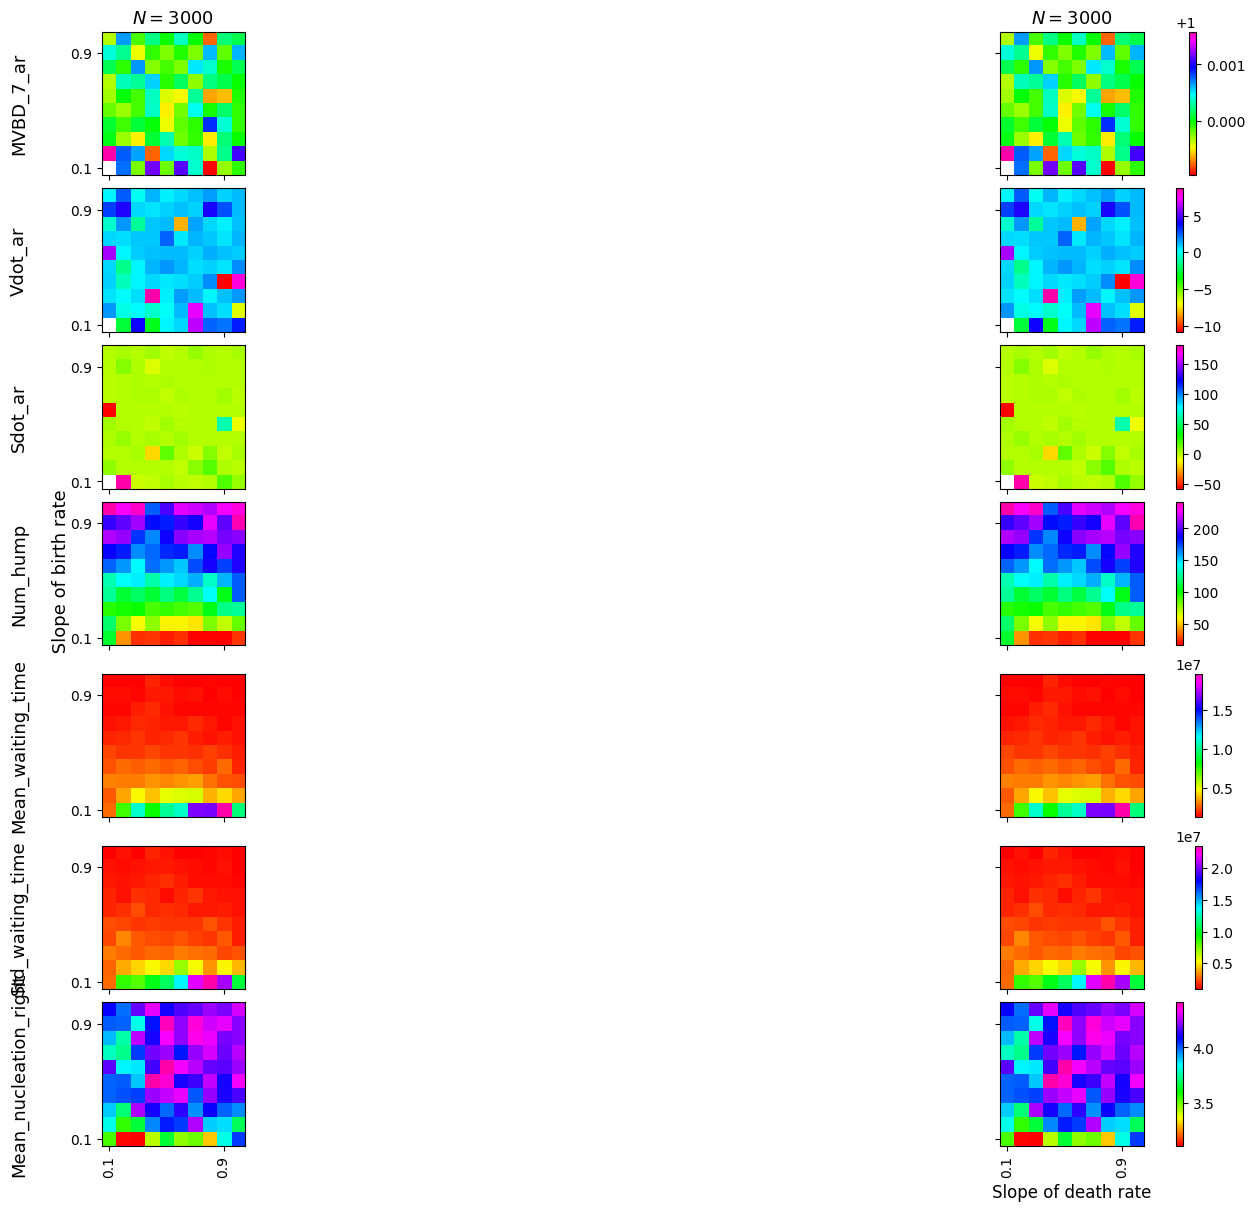

In [17]:
plot_NxM(blist, dlist, nlist, f"March 11", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(14, 12), dpi=600, rowssharecolorbar=True, pltshow = True, figtitle = 0 )





In [2]:
nlist = np.array([50 ,100, 500, 1000, 5000]) # 10, 50 ,100, 500, 1000, 5000, 10000
b1list = blist = np.arange(0,1.001 ,0.025)   
d1list = dlist = np.arange(0,1.001 ,0.025) 
b2list = np.array([0])
d2list = np.array([0])
tmax = 530000 
transient = np.array([1, 30000])      
t_lag  = 50
t_lag2 = 1
nansa  = 1
save_dir=f"C:/Results/Fitnesswaves/T4_Quad_N({nlist[0]},{nlist[-1]})_b1({b1list[0]},{b1list[-1]})_b2({b2list[0]},{b2list[-1]})_d1({d1list[0]},{d1list[-1]})_d2({d2list[0]},{d2list[-1]})_tmax({tmax})_tlag({t_lag})_transient({int(transient[0])},{int(transient[1])})_nansa({nansa})"
df = pd.read_csv(os.path.join(save_dir, "50_ALL_summaries.csv"))
df = df.sort_values(["N", "b1","b2", "d1", "d2"]).reset_index(drop=True)
df

,N,b1,b2,d1,d2,Avg_bclipped,Avg_dclipped,Avg_bdclipped,Avg_b_clip_mass,Avg_d_clip_mass,...,P4d_avg,P5b_avg,P5d_avg,MVbd_eff_mass_clip_rt,MVbd_eff_count_clip_rt,Delta_odd,Peak_height,curvature,Integrated_response,Weighted_asym
0,50,0.0,0.0,0.000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,-0.729930,0.302217,-59.408820,-0.026385,-0.078806
1,50,0.0,0.0,0.025,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,NaN,0.000000,1.130857,1.130857,-0.417580,0.479508,52.399365,2.217748,-0.027888
2,50,0.0,0.0,0.050,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,NaN,0.000000,1.063490,1.063490,-0.373448,0.544691,-8.044713,3.091194,-0.024905
3,50,0.0,0.0,0.075,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000004,NaN,0.000001,1.078139,1.078139,-0.331193,0.619518,-83.191643,3.884003,0.005190
4,50,0.0,0.0,0.100,0.0,0.000000,0.000028,0.000028,0.000000,0.000001,...,0.000166,NaN,0.000071,1.073015,1.073448,-0.080716,0.651245,50.380469,4.561015,0.012830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8400,5000,1.0,0.0,0.900,0.0,0.387883,0.379892,0.767775,0.336281,0.319192,...,-0.131622,-28.396310,29.194200,0.474127,0.521325,0.490592,3.527636,8.350059,53.990972,0.134763
8401,5000,1.0,0.0,0.925,0.0,0.385107,0.379338,0.764445,0.331804,0.318964,...,-0.272962,-34.156635,39.233747,0.475062,0.521805,0.762347,3.399053,-16.613523,52.026173,0.024902
8402,5000,1.0,0.0,0.950,0.0,0.386956,0.382914,0.769870,0.333365,0.325114,...,0.230915,-36.726671,39.489344,0.464926,0.509055,-0.352963,4.403066,-475.777623,53.339252,-0.065377
8403,5000,1.0,0.0,0.975,0.0,0.388030,0.386410,0.774440,0.334427,0.330414,...,0.100618,-33.068777,35.588895,0.456966,0.498912,-0.414355,3.705214,-32.711463,53.664141,0.434997


In [3]:
selected_n_values = [50, 100, 500, 1000, 5000] 
dpi = 1200
mvbd1_rt = ("mvbd1_ar", "MVbd_rt")
mvbd2_rt = ("mvbd2_ar", "MVbd_rt_ES")
mvbd3_rt = ("mvbd3_ar", "MVbd_rt_ES2")
mvbd4_rt = ("mvbd4_ar", "New_MVbd_rt")
mvbd5_rt = ("mvbd5_ar", "New_MVbd_rt_ES")
mvbd6_rt = ("mvbd6_ar", "New_MVbd_rt_ES2")
mvbd7_rt = ("mvbd7_ar", "final_MVbd_rt")


fields = [mvbd1_rt, mvbd2_rt, mvbd3_rt, mvbd4_rt, mvbd5_rt, mvbd6_rt, mvbd7_rt]
plot_NxM_BW_MVBD_share_all(blist, dlist, nlist, f"Feb 19 Pre BW shareall", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_BW_MVBD(blist, dlist, nlist, f"Feb 19 Pre BW", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_share_all(blist, dlist, nlist, f"Feb 19 Pre shareall", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15,15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 

mvbd1 = ("mvbd1_ra", "MVbd")
mvbd2 = ("mvbd2_ra", "MVbd_ES")
mvbd3 = ("mvbd3_ra", "MVbd_ES2")
mvbd4 = ("mvbd4_ra", "New_MVbd")
mvbd5 = ("mvbd5_ra", "New_MVbd_ES")
mvbd6 = ("mvbd6_ra", "New_MVbd_ES2")
mvbd7 = ("mvbd7_ra", "final_MVbd")

fields = [mvbd1, mvbd2, mvbd3, mvbd4, mvbd5, mvbd6, mvbd7]
plot_NxM_BW_MVBD_share_all(blist, dlist, nlist, f"Feb 19 Pre BW shareall", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_BW_MVBD(blist, dlist, nlist, f"Feb 19 Pre BW", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_share_all(blist, dlist, nlist, f"Feb 19 Pre shareall", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15,15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 



In [4]:
df["dif_mvbd"] = np.abs(df["MVbd_rt"] - df["MVbd"])
df["dif_MVbd_ES"] = np.abs(df["MVbd_rt_ES"] - df["MVbd_ES"])
df["dif_MVbd_ES2"] = np.abs(df["MVbd_rt_ES2"] - df["MVbd_ES2"])
df["dif_New_MVbd"] = np.abs(df["New_MVbd_rt"] - df["New_MVbd"])
df["dif_New_MVbd_ES"] = np.abs(df["New_MVbd_rt_ES"] - df["New_MVbd_ES"])
df["dif_New_MVbd_ES2"] = np.abs(df["New_MVbd_rt_ES2"] - df["New_MVbd_ES2"])
df["diff_final_MVbd"] = np.abs(df["final_MVbd"] - df["final_MVbd_rt"])

dif1 = ("dif1", "dif_mvbd")
dif2 = ("dif2", "dif_MVbd_ES")
dif3 = ("dif3", "dif_MVbd_ES2")
dif4 = ("dif4", "dif_New_MVbd")
dif5 = ("dif5", "dif_New_MVbd_ES")
dif6 = ("dif6", "dif_New_MVbd_ES2")
dif7 = ("dif7", "diff_final_MVbd")

fields = [dif1, dif2, dif3, dif4, dif5, dif6, dif7]
# plot_NxM_BW_MVBD_share_all(blist, dlist, nlist, f"dif 51_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
# plot_NxM_BW_MVBD(blist, dlist, nlist, f"dif _ 52_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_share_all(blist, dlist, nlist, f"Feb 19 diff", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15,15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [ ]:
selected_n_values = [50, 100, 500, 1000, 5000] 
dpi = 600

mvbd_rt = (r"$\mathrm{ \frac{  \langle\dot M \rangle}{ \langle V\rangle  (b+d)} }$", "MVbd")
MVbd_rt_ES = (r"$\mathrm{ \frac{ \langle\dot M \rangle }{ \langle V\rangle  (b+d-bP_b-dP_d)} }$", "MVbd_ES")
mass_MVbd_rt = ("mass_MVbd_rt", "mass_MVbd_rt")
New_mvbd_rt = (r"$\mathrm{ \frac{  \langle\dot M \rangle }{ \langle V\rangle  \langle(b_{eff}+d_{eff})\langle } }$", "New_MVbd")
New_MVbd_rt_ES = (r"$\mathrm{ \frac{ \langle\dot M \rangle }{ \langle V\rangle  \langle(b_{eff}+d_{eff}-P_bb_{eff}-P_dd_{eff})\langle} }$", "New_MVbd_ES")

fields = [mvbd_rt, MVbd_rt_ES, mass_MVbd_rt, New_mvbd_rt, New_MVbd_rt_ES]
plot_NxM_BW_MVBD_share_all(blist, dlist, nlist, f"Feb 12 _ 51_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_BW_MVBD(blist, dlist, nlist, f"Feb 12 _ 52_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_share_all(blist, dlist, nlist, f"Feb 12 _ 53_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15,15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [ ]:
mvbd_rt = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b+d)} \rangle}$", "MVbd_rt")
MVbd_rt_ES = (r"$\mathrm{\langle \frac{ \dot M }{ V  (b+d-bP_b-dP_d)} \rangle}$", "MVbd_rt_ES")
MVbd_rt_ES2 = (r"$\mathrm{\langle \frac{ \dot M }{ V  (b+d-bP_b + \frac{1}{N} \Sigma{\frac{1}{x_{left tail}}} -dP_d + \frac{1}{N} \Sigma{\frac{1}{x_{right tail}}})  } \rangle}$", "MVbd_rt_ES2")

New_mvbd_rt = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b_{eff}+d_{eff})} \rangle}$", "New_MVbd_rt")
New_MVbd_rt_ES = (r"$\mathrm{\langle \frac{ \dot M }{ V  (b_{eff}+d_{eff}-P_bb_{eff}-P_dd_{eff})} \rangle}$", "New_MVbd_rt_ES")
New_MVbd_rt_ES2 = (r"$\mathrm{\langle \frac{ \dot M }{ V  (b_{eff}+d_{eff}-b_{eff}P_b + \frac{1}{N} \Sigma{\frac{1}{x_{left tail}}} -d_{eff}P_d + \frac{1}{N} \Sigma{\frac{1}{x_{right tail}}})  } \rangle}$", "New_MVbd_rt_ES2")


mvbd_rt = (r"$\mathrm{ \frac{  \langle\dot M \rangle}{ \langle V\rangle  (b+d)} }$", "MVbd")
MVbd_rt_ES = (r"$\mathrm{ \frac{ \langle\dot M \rangle }{ \langle V\rangle  (b+d-bP_b-dP_d)} }$", "MVbd_ES")
MVbd_rt_ES2 = (r"$\mathrm{ \frac{ \langle\dot M \rangle }{ \langle V\rangle  (b+d-bP_b + \frac{1}{N} \Sigma{\frac{1}{x_{left tail}}} -dP_d + \frac{1}{N} \Sigma{\frac{1}{x_{right tail}}})  } }$", "MVbd_ES2")

New_mvbd_rt = (r"$\mathrm{ \frac{  \langle\dot M \rangle }{ \langle V\rangle  \langle(b_{eff}+d_{eff})\langle } }$", "New_MVbd")
New_MVbd_rt_ES = (r"$\mathrm{ \frac{ \langle\dot M \rangle }{ \langle V\rangle  \langle(b_{eff}+d_{eff}-P_bb_{eff}-P_dd_{eff})\langle} }$", "New_MVbd_ES")
New_MVbd_rt_ES2 = (r"$\mathrm{ \frac{ \langle\dot M \rangle }{ \langle V\rangle  \langle(b_{eff}+d_{eff}-b_{eff}P_b + \frac{1}{N} \Sigma{\frac{1}{x_{left tail}}} -d_{eff}P_d + \frac{1}{N} \Sigma{\frac{1}{x_{right tail}}})\langle  } }$", "New_MVbd_ES2")


In [83]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [7]:
selected_n_values = [50, 100, 500, 1000, 5000] 
dpi = 600

In [17]:
New2_MVbd_rt_ES = ("New2_MVbd_rt_ES", "New2_MVbd_rt_ES")
New2_MVbd_rt = ("New2_MVbd_rt", "New2_MVbd_rt")

mvbd1_rt = ("mvbd1_ra", "MVbd_rt")
mvbd2_rt = ("mvbd2_ra", "MVbd_rt_ES")

mvbd4_rt = ("mvbd4_ra", "New_MVbd_rt")
mvbd5_rt = ("mvbd5_ra", "New_MVbd_rt_ES")


fields = [mvbd1_rt, mvbd2_rt, mvbd4_rt, mvbd5_rt, New2_MVbd_rt, New2_MVbd_rt_ES]
plot_NxM_BW_MVBD_share_all(blist, dlist, nlist, f"test Feb 13 Pre BW shareall", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_BW_MVBD(blist, dlist, nlist, f"test Feb 13 Pre BW", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_share_all(blist, dlist, nlist, f"test Feb 13 Pre shareall", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15,15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [11]:
mvbd1_rt = ("mvbd1_ra", "MVbd_rt")
mvbd2_rt = ("mvbd2_ra", "MVbd_rt_ES")
mvbd3_rt = ("mvbd3_ra", "MVbd_rt_ES2")
mvbd4_rt = ("mvbd4_ra", "New_MVbd_rt")
mvbd5_rt = ("mvbd5_ra", "New_MVbd_rt_ES")
mvbd6_rt = ("mvbd6_ra", "New_MVbd_rt_ES2")

fields = [mvbd1_rt, mvbd2_rt, mvbd3_rt, mvbd4_rt, mvbd5_rt, mvbd6_rt]
plot_NxM_BW_MVBD_share_all(blist, dlist, nlist, f"Feb 13 Pre BW shareall", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_BW_MVBD(blist, dlist, nlist, f"Feb 13 Pre BW", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_share_all(blist, dlist, nlist, f"Feb 13 Pre shareall", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15,15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 

mvbd1 = ("mvbd1_ar", "MVbd")
mvbd2 = ("mvbd2_ar", "MVbd_ES")
mvbd3 = ("mvbd3_ar", "MVbd_ES2")
mvbd4 = ("mvbd4_ar", "New_MVbd")
mvbd5 = ("mvbd5_ar", "New_MVbd_ES")
mvbd6 = ("mvbd6_ar", "New_MVbd_ES2")

fields = [mvbd1, mvbd2, mvbd3, mvbd4, mvbd5, mvbd6]
plot_NxM_BW_MVBD_share_all(blist, dlist, nlist, f"Feb 13 Pre BW shareall", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_BW_MVBD(blist, dlist, nlist, f"Feb 13 Pre BW", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_share_all(blist, dlist, nlist, f"Feb 13 Pre shareall", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15,15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 



In [100]:
selected_n_values = [50, 100, 500, 1000, 5000] 
dpi = 600

mvbd_rt = (r"$\mathrm{ \frac{  \langle\dot M \rangle}{ \langle V\rangle  (b+d)} }$", "MVbd")
MVbd_rt_ES = (r"$\mathrm{ \frac{ \langle\dot M \rangle }{ \langle V\rangle  (b+d-bP_b-dP_d)} }$", "MVbd_ES")
MVbd_rt_ES2 = (r"$\mathrm{ \frac{ \langle\dot M \rangle }{ \langle V\rangle  (b+d-bP_b + \frac{1}{N} \Sigma{\frac{1}{x_{left tail}}} -dP_d + \frac{1}{N} \Sigma{\frac{1}{x_{right tail}}})  } }$", "MVbd_ES2")

New_mvbd_rt = (r"$\mathrm{ \frac{  \langle\dot M \rangle }{ \langle V\rangle  \langle(b_{eff}+d_{eff})\langle } }$", "New_MVbd")
New_MVbd_rt_ES = (r"$\mathrm{ \frac{ \langle\dot M \rangle }{ \langle V\rangle  \langle(b_{eff}+d_{eff}-P_bb_{eff}-P_dd_{eff})\langle} }$", "New_MVbd_ES")
New_MVbd_rt_ES2 = (r"$\mathrm{ \frac{ \langle\dot M \rangle }{ \langle V\rangle  \langle(b_{eff}+d_{eff}-b_{eff}P_b + \frac{1}{N} \Sigma{\frac{1}{x_{left tail}}} -d_{eff}P_d + \frac{1}{N} \Sigma{\frac{1}{x_{right tail}}})\langle  } }$", "New_MVbd_ES2")

fields = [mvbd_rt, MVbd_rt_ES, MVbd_rt_ES2, New_mvbd_rt, New_MVbd_rt_ES, New_MVbd_rt_ES2]
plot_NxM_BW_MVBD_share_all(blist, dlist, nlist, f"Feb 12 _ 51_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_BW_MVBD(blist, dlist, nlist, f"Feb 12 _ 52_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_share_all(blist, dlist, nlist, f"Feb 12 _ 53_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15,15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [39]:
df["dif_mvbd"] = np.abs(df["MVbd_rt"] - df["MVbd"])
df["dif_MVbd_ES"] = np.abs(df["MVbd_rt_ES"] - df["MVbd_ES"])
df["dif_MVbd_ES2"] = np.abs(df["MVbd_rt_ES2"] - df["MVbd_ES2"])
df["dif_New_MVbd"] = np.abs(df["New_MVbd_rt"] - df["New_MVbd"])
df["dif_New_MVbd_ES"] = np.abs(df["New_MVbd_rt_ES"] - df["New_MVbd_ES"])
df["dif_New_MVbd_ES2"] = np.abs(df["New_MVbd_rt_ES2"] - df["New_MVbd_ES2"])
df["diff_final_MVbd"] = np.abs(df["final_MVbd"] - df["final_MVbd_rt"])

In [34]:
dif1 = ("dif1", "dif_mvbd")
dif2 = ("dif2", "dif_MVbd_ES")
dif3 = ("dif3", "dif_MVbd_ES2")
dif4 = ("dif4", "dif_New_MVbd")
dif5 = ("dif5", "dif_New_MVbd_ES")
dif6 = ("dif6", "dif_New_MVbd_ES2")
dif7 = ("dif7", "diff_final_MVbd")

fields = [dif1, dif2, dif3, dif4, dif5, dif6, dif7]
# plot_NxM_BW_MVBD_share_all(blist, dlist, nlist, f"dif 51_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
# plot_NxM_BW_MVBD(blist, dlist, nlist, f"dif _ 52_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_share_all(blist, dlist, nlist, f"Feb 13 diff", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15,15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [14]:
selected_n_values = [50, 100, 500, 1000, 5000] 
dpi = 300

mvbd_rt = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b+d)} \rangle}$", "MVbd_rt")

low, high = 0.25, 1.75
df["MVbd_S_Method_3"] = df["MVbd_S_Method_3"].where(df["MVbd_S_Method_3"].between(low, high), np.nan)


MVbd_S_Method_1 = ("MVbd_S_1", "MVbd_S_Method_1")
MVbd_S_Method_2 = ("MVbd_S_2", "MVbd_S_Method_2")
MVbd_S_Method_3 = ("MVbd_S_3", "MVbd_S_Method_3")

fields = [mvbd_rt, MVbd_S_Method_1, MVbd_S_Method_2, MVbd_S_Method_3]

plot_NxM_BW_MVBD_share_all(blist, dlist, nlist, f"test13", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 10), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [ ]:
selected_n_values = [50, 100, 500, 1000, 5000] 
dpi = 300

mvbd_rt = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b+d)} \rangle}$", "MVbd_rt")
MVbd_rt_ES = (r"$\mathrm{\langle \frac{ \dot M }{ V  (b+d-bP_b-dP_d)} \rangle}$", "MVbd_rt_ES")
MVbd_rt_ES2 = (r"$\mathrm{\langle \frac{ \dot M }{ V  (b+d-bP_b + \frac{1}{N} \Sigma{\frac{1}{x_{left tail}}} -dP_d + \frac{1}{N} \Sigma{\frac{1}{x_{right tail}}})  } \rangle}$", "MVbd_rt_ES2")

New_mvbd_rt = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b_{eff}+d_{eff})} \rangle}$", "New_MVbd_rt")
New_MVbd_rt_ES = (r"$\mathrm{\langle \frac{ \dot M }{ V  (b_{eff}+d_{eff}-P_bb_{eff}-P_dd_{eff})} \rangle}$", "New_MVbd_rt_ES")
New_MVbd_rt_ES2 = (r"$\mathrm{\langle \frac{ \dot M }{ V  (b_{eff}+d_{eff}-b_{eff}P_b + \frac{1}{N} \Sigma{\frac{1}{x_{left tail}}} -d_{eff}P_d + \frac{1}{N} \Sigma{\frac{1}{x_{right tail}}})  } \rangle}$", "New_MVbd_rt_ES2")


fields = [mvbd_rt, MVbd_rt_ES, MVbd_rt_ES2, New_mvbd_rt, New_MVbd_rt_ES, New_MVbd_rt_ES2]
plot_NxM_BW_MVBD_share_all(blist, dlist, nlist, f"Feb 10 _ 51_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_BW_MVBD(blist, dlist, nlist, f"Feb 10 _ 52_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_share_all(blist, dlist, nlist, f"Feb 10 _ 53_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15,15), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [9]:
selected_n_values = [50, 100, 500, 1000, 5000] 
dpi = 300

mvbd_rt = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b+d)} \rangle}$", "MVbd_rt")
MVbd_rt_ES = (r"$\mathrm{\langle \frac{ \dot M }{ V  (b+d-bP_b-dP_d)} \rangle}$", "MVbd_rt_ES")

New_mvbd_rt = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b_{eff}+d_{eff})} \rangle}$", "New_MVbd_rt")
New_MVbd_rt_ES = (r"$\mathrm{\langle \frac{ \dot M }{ V  (b_{eff}+d_{eff}-P_bb_{eff}-P_dd_{eff})} \rangle}$", "New_MVbd_rt_ES")
New2_MVbd_rt = ("New2_MVbd_rt", "New2_MVbd_rt")
New2_MVbd_rt_ES = (r"$\mathrm{\langle \frac{ \dot M }{ V  (b_{eff}+d_{eff}-P_bb_{eff}-P_dd_{eff})} \rangle}$", "New2_MVbd_rt_ES")


fields = [mvbd_rt, MVbd_rt_ES, New_mvbd_rt, New_MVbd_rt_ES, New2_MVbd_rt, New2_MVbd_rt_ES]
plot_NxM_BW_MVBD_share_all(blist, dlist, nlist, f"Feb 13 _ 51_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 12.5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_BW_MVBD(blist, dlist, nlist, f"Feb 13 _ 52_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 12.5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_share_all(blist, dlist, nlist, f"Feb 13 _ 53_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15,12.5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [5]:
Mean_Slope = ("Mean_Slope", "Mean_Slope")
Avg_M_dot_rt = ("Avg_M_dot_rt", "Avg_M_dot_rt")
Theo_M_dot_rt = ("Theo_M_dot_rt", "Theo_M_dot_rt")
Theo_M_dot2_rt = ("Theo_M_dot2_rt", "Theo_M_dot2_rt")
M_dot_var_based = ("M_dot_var_based", "M_dot_var_based")
NEW_M_dot_var_based = ("NEW_M_dot_var_based", "NEW_M_dot_var_based")
fields = [Avg_M_dot_rt, Theo_M_dot_rt, Theo_M_dot2_rt, M_dot_var_based, NEW_M_dot_var_based]
plot_NxM(blist, dlist, nlist, f"Feb 12 _ 54_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 13), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [ ]:
df["dif1"] = df["Avg_M_dot_rt"] - df["Theo_M_dot_rt"]
df["dif2"] = df["Avg_M_dot_rt"] - df["Theo_M_dot2_rt"]

dif1 = ("dif1", "dif1")
dif2 = ("dif2", "dif2")

fields = [dif1, dif2]
plot_NxM(blist, dlist, nlist, f"Feb 10 _ 55_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [29]:
selected_n_values = [50, 100, 500, 1000, 5000] 
dpi = 300

mvbd_rt = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b+d)} \rangle}$", "MVbd_rt")

# low, high = 0.25, 1.75
# df["MVbd_S_Method_3"] = df["MVbd_S_Method_3"].where(df["MVbd_S_Method_3"].between(low, high), np.nan)

MVbd_rt_2nd_term = ("MVbd_1/x_2nd", "MVbd_rt_2nd_term")
MVbd_rt_3rd_term = ("MVbd_1/x_3rd", "MVbd_rt_3rd_term")
MVbd_rt_4th_term = ("MVbd_1/x_4th", "MVbd_rt_4th_term")

fields = [mvbd_rt, MVbd_rt_2nd_term, MVbd_rt_3rd_term, MVbd_rt_4th_term]
plot_NxM_BW_MVBD_share_all(blist, dlist, nlist, f"Feb 10 _ 52_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 10), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_share_all(blist, dlist, nlist, f"Feb 10 _ 53_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 10), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [30]:
plot_NxM_BW_MVBD(blist, dlist, nlist, f"Feb 10 _ 52_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 10), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM(blist, dlist, nlist, f"Feb 10 _ 53_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 10), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [41]:
selected_n_values = [50, 100, 500, 1000, 5000] 
dpi = 300

mvbd_rt = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b+d)} \rangle}$", "MVbd_rt")

# low, high = 0.25, 1.75
# df["MVbd_S_Method_3"] = df["MVbd_S_Method_3"].where(df["MVbd_S_Method_3"].between(low, high), np.nan)

MVbd_S_Method_1 = ("MVbd_S_1", "NEW_MVbd_S_Method_1")
MVbd_S_Method_2 = ("MVbd_S_2", "NEW_MVbd_S_Method_2")
MVbd_S_Method_3 = ("MVbd_S_3", "NEW_MVbd_S_Method_3")

fields = [mvbd_rt, MVbd_S_Method_1, MVbd_S_Method_2, MVbd_S_Method_3]
plot_NxM_BW_MVBD_share_all(blist, dlist, nlist, f"Feb 10 _ 52_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 10), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_share_all(blist, dlist, nlist, f"Feb 10 _ 53_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 10), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [ ]:
selected_n_values = [50, 100, 500, 1000, 5000] 
dpi = 300

mvbd_rt = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b+d)} \rangle}$", "MVbd_rt")

low, high = 0.25, 1.75

df["MVbd_S_Method_3"] = df["MVbd_S_Method_3"].where(df["MVbd_S_Method_3"].between(low, high), np.nan)

MVbd_S_Method_1 = ("MVbd_S_1", "MVbd_S_Method_1")
MVbd_S_Method_2 = ("MVbd_S_2", "MVbd_S_Method_2")
MVbd_S_Method_3 = ("MVbd_S_3", "MVbd_S_Method_3")

fields = [mvbd_rt, MVbd_S_Method_1, MVbd_S_Method_2, MVbd_S_Method_3]
plot_NxM_BW_MVBD_share_all(blist, dlist, nlist, f"Feb 10 _ 52_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 10), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_share_all(blist, dlist, nlist, f"Feb 10 _ 53_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 10), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


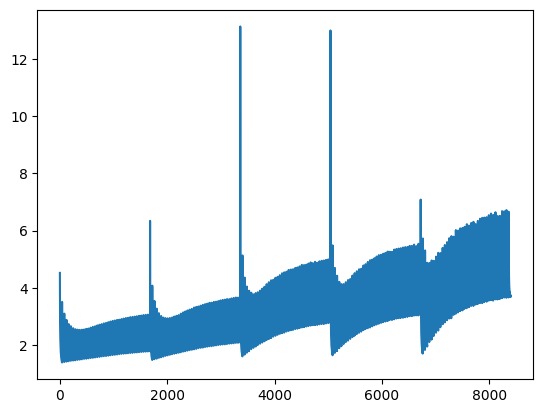

In [26]:
plt.plot(df["Avg_Std"])

In [21]:
plot_NxM_BW_MVBD(blist, dlist, nlist, f"Feb 10 _ 52_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 10), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM(blist, dlist, nlist, f"Feb 10 _ 53_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 10), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [19]:
Mean_Slope = ("Mean_Slope", "Mean_Slope")
Avg_M_dot_rt = ("Avg_M_dot_rt", "Avg_M_dot_rt")
Theo_M_dot_rt = ("Theo_M_dot_rt", "Theo_M_dot_rt")
Theo_M_dot2_rt = ("Theo_M_dot2_rt", "Theo_M_dot2_rt")
fields = [Mean_Slope, Avg_M_dot_rt, Theo_M_dot_rt, Theo_M_dot2_rt]
plot_NxM(blist, dlist, nlist, f"Feb 10 _ 54_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 10), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [18]:
df["dif1"] = df["Avg_M_dot_rt"] - df["Theo_M_dot_rt"]
df["dif2"] = df["Avg_M_dot_rt"] - df["Theo_M_dot2_rt"]

dif1 = ("dif1", "dif1")
dif2 = ("dif2", "dif2")

fields = [dif1, dif2]
plot_NxM(blist, dlist, nlist, f"Feb 10 _ 55_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [36]:
df.columns

Index(['N', 'b1', 'b2', 'd1', 'd2', 'Avg_bclipped', 'Avg_dclipped',
       'Avg_bdclipped', 'Avg_b_clip_mass', 'Avg_d_clip_mass',
       'Avg_bd_clip_mass', 'Avg_Skw', 'std_Skw', 'Avg_Std', 'std_Std',
       'Avg_Var', 'std_Var', 'Avg_Amp_2D', 'Avg_Phase_2D', 'Avg_Freq_2D',
       'Std_Freq_2D', 'Avg_Abs_Freq_2D', 'Avg_Amp_Hil_std',
       'Avg_Phase_Hil_std', 'Avg_Freq_Hil_std', 'Avg_Abs_Freq_Hil_std',
       'Std_Freq_Hil_std', 'Avg_Amp_Hil_skw', 'Avg_Phase_Hil_skw',
       'Avg_Freq_Hil_skw', 'Avg_Abs_Freq_Hil_skw', 'Std_Freq_Hil_skw',
       'final_mean_trait', 'Mean_Slope', 'Mean_Intercept', 'Avg_M_dot_rt',
       'Std_M_dot_rt', 'MVbd_rt', 'New_MVbd_rt', 'New_MVbd_rt_ES',
       'New_MVbd_rt_ES2', 'Theo_M_dot_rt', 'Theo_M_dot2_rt', 'Theo_M_vbd_rt',
       'Theo_M_vbd_rt2', 'Eff_Slope', 'Eff_Slope2', 'MVbd_rt_ES',
       'MVbd_rt_ES2', 'MVbd_rt_2nd_term', 'MVbd_rt_3rd_term',
       'MVbd_rt_4th_term', 'MVbd_rt_5th_term', 'MVbd_S_Method_1',
       'MVbd_S_Method_2', 'MVbd_S_Method_

In [ ]:
selected_n_values = [300, 500]  # , 10000
dpi = 300

mvbd_rt = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b+d)} \rangle}$", "MVbd_rt")
mvbd_es_rt2 = (r"$\mathrm{\langle \frac{ \dot M }{ V * New Slope } \rangle}$", "MVbd_rt_ES2")
Theomvbd = (r"$\mathrm{ \frac{ Theo \ \dot M }{ V  New Slope} }$", "Theo_M_vbd_rt")
Theomvbd2 = (r"$\mathrm{ \frac{ Theo \ \dot M 2 }{ V  New Slope} }$", "Theo_M_vbd_rt2")

fields = [mvbd_rt, mvbd_es_rt2, Theomvbd, Theomvbd2]
plot_NxM_BW_MVBD_share_all(blist, dlist, nlist, f"Jan 4 _ 52_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(10, 10), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_share_all(blist, dlist, nlist, f"Jan 4 _ 53_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(10, 10), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 



In [10]:
df["Theo_M_dot_rt"] - df["Theo_M_dot2_rt"]

0               NaN
1      0.000000e+00
2      0.000000e+00
3      0.000000e+00
4      2.220446e-16
           ...     
877    0.000000e+00
878    0.000000e+00
879    0.000000e+00
880    0.000000e+00
881    1.776357e-15
Length: 882, dtype: float64

In [9]:
selected_n_values = [300, 500]  # , 10000
dpi = 300

m1 = ("Avg_M_dot_rt", "Avg_M_dot_rt")


m3 = ("Theo_M_dot_rt", "Theo_M_dot_rt")

m4 = ("Theo_M_dot2_rt", "Theo_M_dot2_rt")

fields = [m1, m3, m4]
plot_NxM_share_all(blist, dlist, nlist, f"Feb 6 _ 53_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 10), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM(blist, dlist, nlist, f"Feb 6 _ 54_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 10), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [27]:
nlist = np.array([100, 300, 500, 700, 900])
b1list = blist = np.arange(0,1.001 ,0.025)   
d1list = dlist = np.arange(0,1.001 ,0.025) 
b2list = np.array([0])
d2list = np.array([0])
tmax = 430000 
transient = np.array([1, 30000])            # transient[0, n]->skip first n precent -  transient[1, n]->skip first n steps
t_lag  = 50
t_lag2 = 1
nansa  = 1
save_dir=f"C:/Results/Fitnesswaves/T4_Quad_N({nlist[0]},{nlist[-1]})_b1({b1list[0]},{b1list[-1]})_b2({b2list[0]},{b2list[-1]})_d1({d1list[0]},{d1list[-1]})_d2({d2list[0]},{d2list[-1]})_tmax({tmax})_tlag({t_lag})_transient({int(transient[0])},{int(transient[1])})_nansa({nansa})"
df = pd.read_csv(os.path.join(save_dir, "50_ALL_summaries.csv"))
df = df.sort_values(["N", "b1","b2", "d1", "d2"]).reset_index(drop=True)
df

,N,b1,b2,d1,d2,Avg_bclipped,Avg_dclipped,Avg_bdclipped,Avg_b_clip_mass,Avg_d_clip_mass,...,MVbd_rt_3rd_term,MVbd_rt_4th_term,MVbd_rt_5th_term,MVbd_eff_mass_clip_rt,MVbd_eff_count_clip_rt,Delta_odd,Peak_height,curvature,Integrated_response,Weighted_asym
0,100,0.0,0.0,0.000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,-0.699358,0.543382,108.279804,-0.004345,-0.053382
1,100,0.0,0.0,0.025,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.023741,1.023741,1.023741,1.023741,1.023741,-0.287713,0.541598,-123.257483,2.703469,-0.017199
2,100,0.0,0.0,0.050,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.005228,1.005228,1.005228,1.005228,1.005228,-0.094322,0.628125,-68.744192,3.768647,0.014509
3,100,0.0,0.0,0.075,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.031374,1.031374,1.031374,1.031374,1.031374,-0.169030,0.733303,53.809149,4.803005,0.037988
4,100,0.0,0.0,0.100,0.0,0.000000,0.000086,0.000086,0.000000,0.000005,...,1.026795,1.026797,1.026792,1.026843,1.027734,-0.077865,0.888756,75.497572,5.584586,0.055726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8400,900,1.0,0.0,0.900,0.0,0.360836,0.351240,0.712075,0.299061,0.278694,...,0.294124,0.344420,0.051199,0.539220,0.600584,-0.229324,3.444962,54.394037,41.853840,-0.059513
8401,900,1.0,0.0,0.925,0.0,0.361218,0.354624,0.715841,0.298725,0.283695,...,0.291008,0.395915,0.050116,0.533420,0.592667,0.678351,3.467269,83.828206,42.125259,0.360832
8402,900,1.0,0.0,0.950,0.0,0.359845,0.356290,0.716135,0.296372,0.286289,...,0.291684,0.233171,0.050162,0.531105,0.588915,-0.157605,3.124383,-102.219802,41.337079,0.095162
8403,900,1.0,0.0,0.975,0.0,0.361181,0.360795,0.721976,0.298079,0.292901,...,0.283476,0.279472,0.046597,0.520904,0.575734,0.630040,3.349580,31.305909,41.798652,0.353815


In [ ]:
selected_n_values = [100, 300, 500, 700, 900]  # , 10000
dpi = 300

mvbd_rt = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b+d)} \rangle}$", "MVbd_rt")

mvbd_es_rt2 = (r"$\mathrm{\langle \frac{ \dot M }{ V * New Slope } \rangle}$", "MVbd_rt_ES2")

Theomvbd = (r"$\mathrm{ \frac{ Theo \ \dot M }{ V  New Slope} }$", "Theo_M_vbd_rt")


fields = [mvbd_rt, mvbd_es_rt2, Theomvbd]
plot_NxM_BW_MVBD_share_all(blist, dlist, nlist, f"Jan 4 _ 52_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 7.5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_share_all(blist, dlist, nlist, f"Jan 4 _ 53_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 7.5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 



In [ ]:
selected_n_values = [100, 300, 500, 700, 900]  # , 10000
dpi = 300

m1 = ("Avg_M_dot_rt", "Avg_M_dot_rt")

m2 = ("$\mathrm{\langle \frac{ \dot M }{ V * New Slope } \rangle}$", "MVbd_rt_ES2")

m3 = ("Theo_M_dot_rt", "Theo_M_dot_rt")


fields = [m1, m2, m3]
plot_NxM_BW_MVBD_share_all(blist, dlist, nlist, f"Jan 4 _ 52_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(15, 7.5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_share_all(blist, dlist, nlist, f"Jan 4 _ 53_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 7.5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 



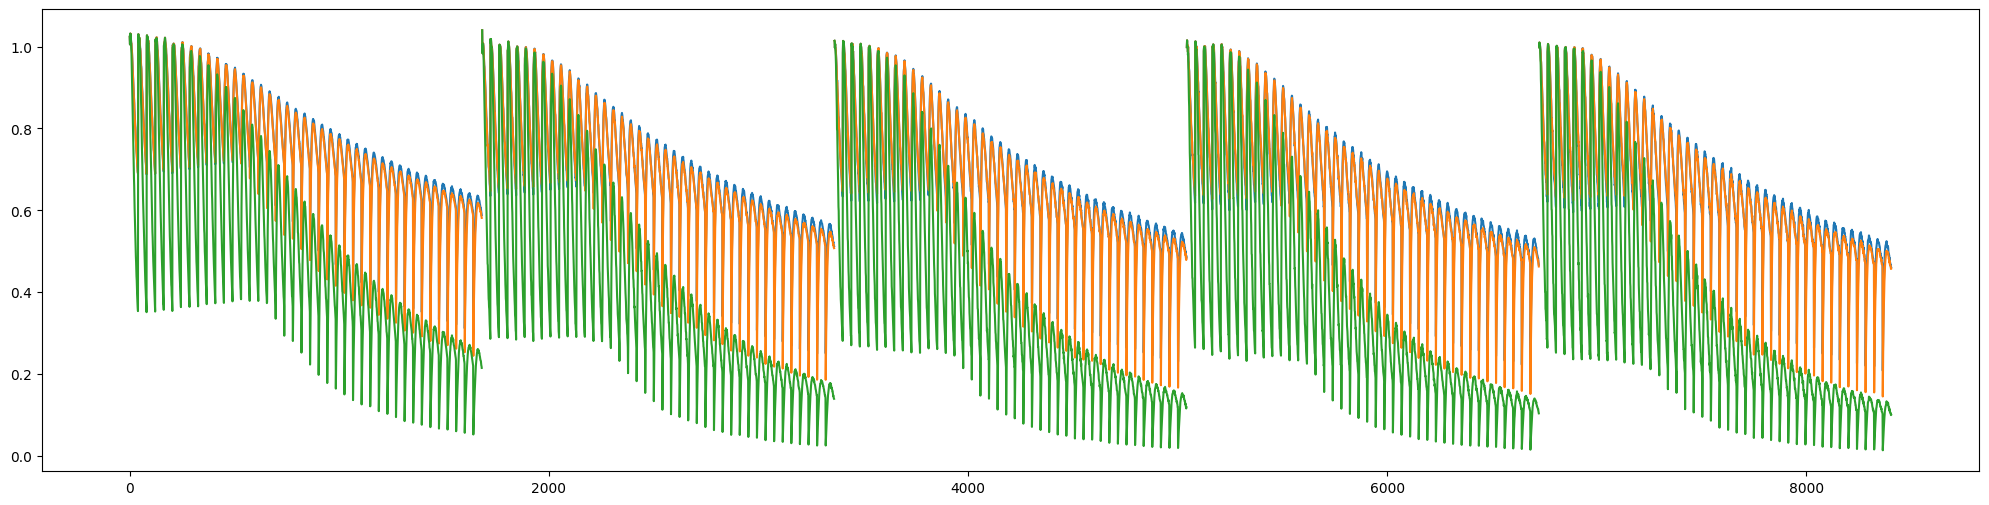

In [17]:
plt.figure(figsize=(25,6))
plt.plot(df["MVbd_rt_ES2"])
plt.plot(df["MVbd_rt_2nd_term"])
plt.plot(df["MVbd_rt_3rd_term"])



In [25]:
selected_n_values = [100, 300, 500, 700, 900] 
fnametitle = "Feb 04 Update_"
dpi = 600


mvbd_rt = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b+d)} \rangle}$", "MVbd_rt")

mvbd_es_rt2 = (r"$\mathrm{\langle \frac{ \dot M }{ V * New Slope } \rangle}$", "MVbd_rt_ES2")

MVbd_rt_2nd_term = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b+d)} \rangle_{2nd\ term}}$", "MVbd_rt_2nd_term")
MVbd_rt_3rd_term = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b+d)} \rangle_{3rd\ term}}$", "MVbd_rt_3rd_term")
MVbd_rt_4th_term = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b+d)} \rangle_{4th\ term}}$", "MVbd_rt_4th_term")
MVbd_rt_5th_term = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b+d)} \rangle_{5th\ term}}$", "MVbd_rt_5th_term")



fields = [mvbd_rt, mvbd_es_rt2, MVbd_rt_2nd_term, MVbd_rt_3rd_term, MVbd_rt_4th_term, MVbd_rt_5th_term]
# plot_NxM(blist, dlist, nlist, fnametitle+f"MVBD_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 12), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_BW_MVBD(blist, dlist, nlist, fnametitle+f"MVBD2_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(18, 12), dpi=dpi, rowssharecolorbar=False, pltshow = False ) 

In [37]:
nlist = np.array([5000, 1000, 500, 100, 50])   
b1list = blist = np.arange(0,1.001 ,0.025)   
d1list = dlist = np.arange(0,1.001 ,0.025) 
b2list = np.array([0])
d2list = np.array([0])
tmax = 430000 
transient = np.array([1, 30000])            # transient[0, n]->skip first n precent -  transient[1, n]->skip first n steps
t_lag  = 10
t_lag2 = 5
nansa  = 1

save_dir=f"C:/Results/Fitnesswaves/T3_Quad_N({nlist[0]},{nlist[-1]})_b1({b1list[0]},{b1list[-1]})_b2({b2list[0]},{b2list[-1]})_d1({d1list[0]},{d1list[-1]})_d2({d2list[0]},{d2list[-1]})_tmax({tmax})_tlag({t_lag})_transient({int(transient[0])},{int(transient[1])})_nansa({nansa})"
df = pd.read_csv(os.path.join(save_dir, "10_ALL_summaries.csv"))
df = df.sort_values(["N", "b1","b2", "d1", "d2"]).reset_index(drop=True)
nlist = np.array([50 ,100, 500, 1000, 5000])
df

,N,b1,b2,d1,d2,Avg_bclipped,Avg_dclipped,Avg_bdclipped,Avg_b_clip_mass,Avg_d_clip_mass,...,Mean_Intercept,Avg_M_dot_rt,Std_M_dot_rt,MVbd_rt,Eff_Slope,Eff_Slope2,MVbd_rt_ES,MVbd_rt_ES2,MVbd_eff_mass_clip_rt,MVbd_eff_count_clip_rt
0,50,0.0,0.0,0.000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,-342.388446,0.013621,0.689995,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN
1,50,0.0,0.0,0.025,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,912.824910,0.328767,0.553846,1.083374,0.025000,0.025000,1.083374,1.083374,1.083374,1.083374
2,50,0.0,0.0,0.050,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,-624.258969,0.505969,0.505080,1.086931,0.050000,0.050000,1.086931,1.086931,1.086931,1.086931
3,50,0.0,0.0,0.075,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,-357.399441,0.631472,0.479695,1.099508,0.075000,0.075000,1.099508,1.099508,1.099508,1.099508
4,50,0.0,0.0,0.100,0.0,0.000000,0.000043,0.000043,0.000000,0.000002,...,1335.399822,0.721975,0.469028,1.078782,0.099996,0.100000,1.078825,1.078784,1.078801,1.079355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8400,5000,1.0,0.0,0.900,0.0,0.382282,0.373263,0.755546,0.328057,0.310278,...,-1671.573421,7.915971,1.559288,0.326057,1.181780,1.468750,0.522484,0.420308,0.489116,0.539433
8401,5000,1.0,0.0,0.925,0.0,0.386107,0.379612,0.765718,0.332500,0.319809,...,-30276.271820,8.149805,1.326553,0.315265,1.187753,1.476321,0.509658,0.409964,0.475449,0.522129
8402,5000,1.0,0.0,0.950,0.0,0.388090,0.384411,0.772501,0.335188,0.326977,...,-2837.779625,8.399508,1.623874,0.306465,1.196719,1.485909,0.497506,0.400572,0.462062,0.505577
8403,5000,1.0,0.0,0.975,0.0,0.386974,0.386592,0.773566,0.333776,0.329516,...,11354.564206,8.324544,1.571860,0.305842,1.211099,1.503896,0.496931,0.400071,0.458625,0.500907


In [11]:
nlist = np.array([10000, 5000, 1000, 500, 100, 50, 10])  # ,     10, 50 ,100, 500, 1000, 5000      
b1list = blist = np.arange(0,1.001 ,0.025)   
d1list = dlist = np.arange(0,1.001 ,0.025) 
b2list = np.array([0])
d2list = np.array([0])
tmax = 530000 
transient = np.array([1, 30000])            # transient[0, n]->skip first n precent -  transient[1, n]->skip first n steps
t_lag  = 10
t_lag2 = 5
nansa  = 10

save_dir=f"C:/Results/Fitnesswaves/T2_Quad_N({nlist[0]},{nlist[-1]})_b1({b1list[0]},{b1list[-1]})_b2({b2list[0]},{b2list[-1]})_d1({d1list[0]},{d1list[-1]})_d2({d2list[0]},{d2list[-1]})_tmax({tmax})_tlag({t_lag})_transient({int(transient[0])},{int(transient[1])})_nansa({nansa})"
df = pd.read_csv(os.path.join(save_dir, "10_ALL_summaries.csv"))
df = df.sort_values(["N", "b1","b2", "d1", "d2"]).reset_index(drop=True)
nlist = np.array([10, 50 ,100, 500, 1000, 5000, 10000])
df

,N,b1,b2,d1,d2,Avg_bclipped,Avg_dclipped,Avg_bdclipped,Avg_b_clip_mass,Avg_d_clip_mass,...,MVbd_eff_mass_clip_rt,MVbd_eff_count_clip_rt,Delta_odd,Peak_height,curvature,Integrated_response,Weighted_asym,M_dot_mu1,M_dot_mu2,M_dot_mu3
0,10,0.0,0.0,0.000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,...,NaN,NaN,-0.276105,0.173778,9.079863,-0.020097,-0.028655,0.000000,0.000000,0.000000
1,10,0.0,0.0,0.025,0.0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,...,1.949640,1.949640,-0.259157,0.203980,12.156640,0.708230,-0.030413,0.109299,0.109299,0.109299
2,10,0.0,0.0,0.050,0.0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,...,1.892483,1.892483,-0.192215,0.210113,16.105784,1.307940,-0.025351,0.201923,0.201923,0.201923
3,10,0.0,0.0,0.075,0.0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,...,1.810774,1.810774,-0.149322,0.232682,2.022626,1.811329,-0.022841,0.285014,0.285014,0.285014
4,10,0.0,0.0,0.100,0.0,0.000000,0.000003,0.000003,0.000000,1.181077e-07,...,1.773844,inf,-0.084973,0.229594,6.627947,2.240679,-0.017407,0.352338,0.352337,0.352339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11762,10000,1.0,0.0,0.900,0.0,0.391848,0.383307,0.775155,0.341299,3.247439e-01,...,0.464696,0.509927,-0.027296,3.215723,12.934709,55.306190,0.114024,8.702157,5.774775,29.863446
11763,10000,1.0,0.0,0.925,0.0,0.393823,0.387885,0.781708,0.343621,3.316483e-01,...,0.453269,0.495634,0.236330,3.359467,28.810427,56.645170,0.385447,8.895163,5.860231,31.404123
11764,10000,1.0,0.0,0.950,0.0,0.393941,0.389999,0.783940,0.343066,3.352742e-01,...,0.447626,0.488347,0.446672,3.528246,33.064836,56.629619,0.388992,8.887434,5.839336,31.753187
11765,10000,1.0,0.0,0.975,0.0,0.393825,0.392495,0.786320,0.342749,3.388704e-01,...,0.441922,0.481004,0.251797,3.288483,-5.647928,56.380277,0.398280,8.859737,5.810374,31.776516


In [4]:
df.columns

Index(['N', 'b1', 'b2', 'd1', 'd2', 'Avg_bclipped', 'Avg_dclipped',
       'Avg_bdclipped', 'Avg_b_clip_mass', 'Avg_d_clip_mass',
       'Avg_bd_clip_mass', 'Avg_Skw', 'std_Skw', 'Avg_Std', 'std_Std',
       'Avg_Var', 'std_Var', 'Avg_Amp_2D', 'Avg_Phase_2D', 'Avg_Freq_2D',
       'Std_Freq_2D', 'Avg_Abs_Freq_2D', 'Avg_Amp_Hil_std',
       'Avg_Phase_Hil_std', 'Avg_Freq_Hil_std', 'Avg_Abs_Freq_Hil_std',
       'Std_Freq_Hil_std', 'Avg_Amp_Hil_skw', 'Avg_Phase_Hil_skw',
       'Avg_Freq_Hil_skw', 'Avg_Abs_Freq_Hil_skw', 'Std_Freq_Hil_skw',
       'final_mean_trait', 'Mean_Slope', 'Mean_Intercept', 'Avg_M_dot_rt',
       'Std_M_dot_rt', 'MVbd_rt', 'MVbd_rt_mu1', 'MVbd_rt_mu2', 'MVbd_rt_mu3',
       'Eff_Slope', 'MVbd_rt_ES', 'MVbd_eff_mass_clip_rt',
       'MVbd_eff_count_clip_rt', 'Delta_odd', 'Peak_height', 'curvature',
       'Integrated_response', 'Weighted_asym', 'M_dot_mu1', 'M_dot_mu2',
       'M_dot_mu3'],
      dtype='object')

In [38]:
df['Abs_Avg_Freq_2D'] = np.abs(df['Avg_Freq_2D'])
df['Mean_Slope_notscaled'] = df['Mean_Slope'] / (df['N'])
df["MVbd"] =  df['Mean_Slope'] / ((df["Avg_Var"]) * ( (df["b1"]+df["d1"]))) 
df['MVbd_eff_count'] = df['Mean_Slope'] / ((df["Avg_Var"]) * ( (df["b1"]+df["d1"])- df["Avg_bdclipped"]))
df['MVbd_eff_mass'] = df['Mean_Slope'] / ((df["Avg_Var"]) * ( (df["b1"]+df["d1"])- df["Avg_bd_clip_mass"]))
df["MVbd_eff_slope"] =  df['Mean_Slope'] / ((df["Avg_Var"]) * df["Eff_Slope"]) 
df["MVbd_eff_slope2"] =  df['Mean_Slope'] / ((df["Avg_Var"]) * df["Eff_Slope2"]) 

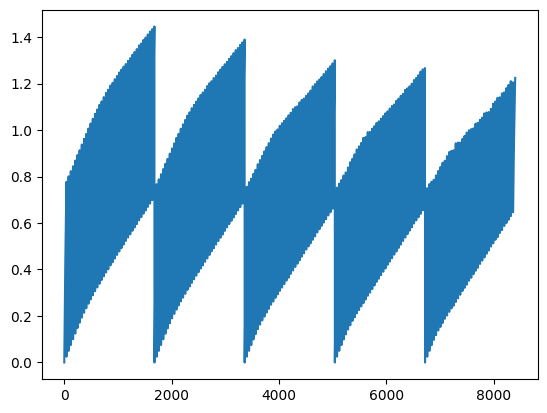

In [33]:
plt.plot(df["Eff_Slope"])

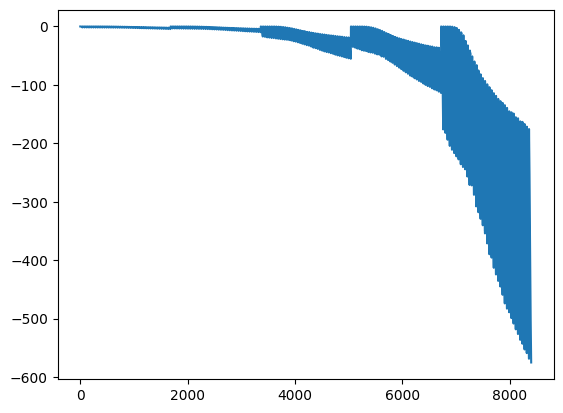

In [30]:
plt.plot(df["Eff_Slope"]- df["Eff_Slope2"])

In [40]:
selected_n_values = [50, 100, 500, 1000, 5000] 
fnametitle = "Jan 27 Update_"
dpi = 600


mvbd_rt = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b+d)} \rangle}$", "MVbd_rt")


mvbd_eff_mass_clip_rt = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b+d - m_{clip})} \rangle}$", "MVbd_eff_mass_clip_rt")


mvbd_es_rt = (r"$\mathrm{\langle \frac{ \dot M }{ V  (b+d-P_bb-P_dd)} \rangle}$", "MVbd_rt_ES")

# mvbd_es_rt2 = (r"$\mathrm{\langle \frac{ \dot M }{ V  (P_b \sum_{left}^{}(d + \frac{1}{|x|})) + (1-P_b-P_d)(b+d) + (P_d \sum_{right}^{}(b + \frac{1}{|x|})) } \rangle}$", "MVbd_rt_ES2")
mvbd_es_rt2 = (r"$\mathrm{\langle \frac{ \dot M }{ V * New Slope } \rangle}$", "MVbd_rt_ES2")


fields = [mvbd_rt, mvbd_eff_mass_clip_rt, mvbd_es_rt, mvbd_es_rt2]
# plot_NxM(blist, dlist, nlist, fnametitle+f"MVBD_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 12), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_BW_MVBD(blist, dlist, nlist, fnametitle+f"MVBD2_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(18, 12), dpi=dpi, rowssharecolorbar=False, pltshow = False ) 

In [6]:
selected_n_values = [50, 100, 500, 1000, 5000] 
fnametitle = "Jan 26 Update_"
dpi = 600

mvbd = (r"$\mathrm{ \frac{ \langle \dot M \rangle}{\langle V \rangle (b+d)} }$", "MVbd")
mvbd_rt = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b+d)} \rangle}$", "MVbd_rt")

mvbd_eff_mass_clip = (r"$\mathrm{ \frac{ \langle \dot M \rangle}{\langle V \rangle (b+d - m_{clip})} }$", "MVbd_eff_mass")
mvbd_eff_mass_clip_rt = (r"$\mathrm{\langle \frac{  \dot M }{ V  (b+d - m_{clip})} \rangle}$", "MVbd_eff_mass_clip_rt")

mvbd_es = (r"$\mathrm{ \frac{ \langle \dot M \rangle}{\langle V \rangle (b+d-P_bb-P_dd)} }$", "MVbd_eff_slope")
mvbd_es_rt = (r"$\mathrm{\langle \frac{ \dot M }{ V  (b+d-P_bb-P_dd)} \rangle}$", "MVbd_rt_ES")

fields = [mvbd, mvbd_rt, mvbd_eff_mass_clip, mvbd_eff_mass_clip_rt, mvbd_es, mvbd_es_rt]
plot_NxM(blist, dlist, nlist, fnametitle+f"MVBD_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 17), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 
plot_NxM_BW_MVBD(blist, dlist, nlist, fnametitle+f"MVBD2_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(18, 17), dpi=dpi, rowssharecolorbar=False, pltshow = False ) 

In [9]:
selected_n_values = [50, 100, 500, 1000, 5000]  # , 10000
fnametitle = "Jan 26 Res"
dpi = 300

# 1
ms  = ("Evolutionary speed \n (Per unit time)", "Mean_Slope")
mss = ("Evolutionary speed \n (Per event)", "Mean_Slope_notscaled")
# eff_ms = ("Eff_Evolutionary speed", "Avg_Eff_Mean_Slope")
fields = [mss, ms]  # , eff_ms
plot_NxM(blist, dlist, nlist, fnametitle+f"1_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 

# 2
avgamp = (r"$\langle \mathrm{Amplitude} \rangle$", "Avg_Amp_2D")
avgfreq = (r"$\langle \mathrm{Frequency} \rangle$", "Abs_Avg_Freq_2D")
fields = [avgamp, avgfreq]
plot_NxM(blist, dlist, nlist, fnametitle+f"2_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 

# 3
df['AmpS'] = df['Avg_Amp_2D'] / df["Avg_Amp_Hil_std"]
avgampskw = (r"$\langle Amp-Hil(skw) \rangle$", "Avg_Amp_Hil_skw")
avgampvar = (r"$\langle Amp-Hil(std) \rangle$", "Avg_Amp_Hil_std")
avgamp = (r"$\langle Amp-2D \rangle$", "Avg_Amp_2D")
AmpS = (r"$\langle \frac{Amp-2D}{Amp-Hil(std)} \rangle$", "AmpS")
fields = [ avgampskw, avgampvar, avgamp, AmpS]
plot_NxM(blist, dlist, nlist, fnametitle+f"3_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 10), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 

# 4
avgfreqhilstd = (r"$\langle Freq-Hil(std) \rangle$", "Avg_Freq_Hil_std")
avgfreqhilskw = (r"$\langle Freq-Hil(skw) \rangle$", "Avg_Freq_Hil_skw")
avgfreq = (r"$\langle \mathrm{Frequency} \rangle$", "Abs_Avg_Freq_2D")
fields = [ avgfreqhilstd, avgfreqhilskw, avgfreq]
plot_NxM(blist, dlist, nlist, fnametitle+f"4_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 7.5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 

# 5
mss = ("Evolutionary speed", "Mean_Slope")
avgvar = (r"$\langle \mathrm{Variance } \rangle$", "Avg_Var")
mvbd = (r"$\mathrm {\dot M/ (\langle v \rangle (b+d))}$", "MVbd")
fields = [mss, avgvar, mvbd]
plot_NxM(blist, dlist, nlist, fnametitle+f"5_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 7.5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


# 6
avgbclip  = (r"$\langle f_{\mathrm{clip}}^{(b)} \rangle$", "Avg_bclipped")
avgdclip  = (r"$\langle f_{\mathrm{clip}}^{(d)} \rangle$", "Avg_dclipped")
avgbdclipp = (r"$\langle f_{\mathrm{clip}} \rangle$", "Avg_bdclipped")
fields = [avgbclip, avgdclip, avgbdclipp]
plot_NxM(blist, dlist, nlist, fnametitle+f"6_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 7.5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


# 7
mvbd = (r"$ \frac{\dot M}{\langle V \rangle (b_1 + d_1)}$", "MVbd")
avgbdclipp = (r"$\langle f_{\mathrm{clip}} \rangle$", "Avg_bdclipped")
effmvbdcount = (r"$ \frac{\dot M}{\langle V \rangle \left[(b_1+d_1)-f_{\mathrm{clip}}\right]}$", "MVbd_eff_count")
fields = [mvbd, avgbdclipp, effmvbdcount]
plot_NxM(blist, dlist, nlist, fnametitle+f"7_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 7.5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


# 8
Avg_b_clip_mass = (r"$\langle m_{\mathrm{clip}}^{(b)} \rangle$", "Avg_b_clip_mass")
Avg_d_clip_mass = (r"$\langle m_{\mathrm{clip}}^{(d)} \rangle$", "Avg_d_clip_mass")
Avg_bd_clip_mass = (r"$\langle m_{\mathrm{clip}} \rangle$", "Avg_bd_clip_mass")
fields = [Avg_b_clip_mass, Avg_d_clip_mass, Avg_bd_clip_mass]
plot_NxM(blist, dlist, nlist, fnametitle+f"8_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 7.5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 

# 9
mvbd = (    r"$\frac{\dot M}{\langle V \rangle (b_1 + d_1)}$",    "MVbd")
Avg_bd_clip_mass = (    r"$\langle m_{\mathrm{clip}} \rangle$",    "Avg_bd_clip_mass")
effmvbdmass = (    r"$\frac{\dot M}{\langle V \rangle \left[(b_1+d_1)-m_{\mathrm{clip}}\right]}$",    "MVbd_eff_mass")
fields = [mvbd, Avg_bd_clip_mass, effmvbdmass]
plot_NxM(blist, dlist, nlist, fnametitle+f"9_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 7.5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 



# 10
mss = (    r"$\dot M$",    "Mean_Slope")
avgvar = (    r"$\langle V \rangle$",    "Avg_Var")
mvbd = (    r"$ \frac{\dot M}{\langle V \rangle (b_1 + d_1)}$",    "MVbd")
effmvbdcount = (    r"$ \frac{\dot M}{\langle V \rangle \left[(b_1+d_1)-f_{\mathrm{clip}}\right]}$",    "MVbd_eff_count")
effmvbdmass = (    r"$ \frac{\dot M}{\langle V \rangle \left[(b_1+d_1)-m_{\mathrm{clip}}\right]}$",    "MVbd_eff_mass")
fields = [mss, avgvar, mvbd, effmvbdcount, effmvbdmass]
plot_NxM(blist, dlist, nlist, fnametitle+f"10_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 12.5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


# 11
mvbd = (r"$\mathrm {\dot M/ (\langle v \rangle (b+d))}$", "MVbd")
effmvbdcount = (r"$ \frac{\dot M}{\langle V \rangle \left[(b+d)-f_{\mathrm{clip}}\right]}$", "MVbd_eff_count")
fields = [mvbd, effmvbdcount]
plot_NxM_BW_MVBD(blist, dlist, nlist, fnametitle+f"11_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(18, 5), dpi=dpi, rowssharecolorbar=False, pltshow = False ) 


# 12
mvbd = (r"$\mathrm {\dot M/ (\langle v \rangle (b+d))}$", "MVbd")
effmvbdmass = (    r"$\frac{\dot M}{\langle V \rangle \left[(b+d)-m_{\mathrm{clip}}\right]}$",    "MVbd_eff_mass")
fields = [mvbd, effmvbdmass]
plot_NxM_BW_MVBD(blist, dlist, nlist, fnametitle+f"12_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(18, 5), dpi=dpi, rowssharecolorbar=False, pltshow = False ) 



In [9]:
selected_n_values = [10, 50, 100, 500, 1000, 5000, 10000]  # , 10000

# 11
mvbd = (r"$\mathrm {\dot M/ (\langle v \rangle (b+d))}$", "MVbd")
effmvbdcount = (r"$ \frac{\dot M}{\langle V \rangle \left[(b+d)-f_{\mathrm{clip}}\right]}$", "eff_MVbd_count")
fields = [mvbd, effmvbdcount]
plot_NxM_BW_MVBD(blist, dlist, nlist, fnametitle+f"11_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(18, 5), dpi=dpi, rowssharecolorbar=False, pltshow = False ) 


# 12
mvbd = (r"$\mathrm {\dot M/ (\langle v \rangle (b+d))}$", "MVbd")
effmvbdmass = (    r"$\frac{\dot M}{\langle V \rangle \left[(b+d)-m_{\mathrm{clip}}\right]}$",    "eff_MVbd_mass")
fields = [mvbd, effmvbdmass]
plot_NxM_BW_MVBD(blist, dlist, nlist, fnametitle+f"12_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("bwr", 0.0, 1), figsize=(18, 5), dpi=dpi, rowssharecolorbar=False, pltshow = False ) 



In [ ]:
avgvar = (r"$\langle \mathrm{Variance } \rangle$", "Avg_Var")
effvar = ("eff_Var", "eff_Var")
avgskw = (r"$\langle skw \rangle$", "Avg_Skw")

mss = ("Evolutionary speed", "Mean_Slope")
Avg_M_dot = ("Avg_M_dot", "Avg_M_dot")
Std_M_dot = ("Std_M_dot", "Std_M_dot")
Delta_odd = ("Delta_odd", "Delta_odd")
Peak_height = ("Peak_height", "Peak_height")
curvature = ("curvature", "curvature")
Integrated_response = ("Integrated_response", "Integrated_response")
Weighted_asym = ("Weighted_asym", "Weighted_asym")


mvbd = (r"$\mathrm {\dot M/ (\langle v \rangle (b+d))}$", "MVbd")
effmvbdcount = (r"$ \frac{\dot M}{\langle V \rangle \left[(b_1+d_1)-f_{\mathrm{clip}}\right]}$", "eff_MVbd_count")

fields = [mss, Std_M_dot, Delta_odd, Peak_height, curvature,Integrated_response, Weighted_asym, mvbd, effmvbdcount]
plot_NxM(blist, dlist, nlist, fnametitle+f"13_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(18, 25), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [51]:
selected_n_values = [10, 50, 100, 500, 900, 5000]
fnametitle = ""
dpi = 300

avgvar = (r"$\langle \mathrm{Variance } \rangle$", "Avg_Var")
effvar = ("eff_Var", "eff_Var")
avgskw = (r"$\langle skw \rangle$", "Avg_Skw")

mss = ("Evolutionary speed", "Mean_Slope")
mvbd = (r"$\mathrm {\dot M/ (\langle v \rangle (b+d))}$", "MVbd")
effmvbdcount = (r"$ \frac{\dot M}{\langle V \rangle \left[(b_1+d_1)-f_{\mathrm{clip}}\right]}$", "eff_MVbd_count")
mvbd1 = ("MVbd222", "MVbd222")
mvbd2 = ("MVbd333", "MVbd333")

fields = [avgvar, effvar,  avgskw, mss, mvbd, effmvbdcount, mvbd1, mvbd2]
plot_NxM(blist, dlist, nlist, fnametitle+f"51_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 20), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [ ]:




avgampskw = (r"$\langle Amp-Hil(skw) \rangle$", "Avg_Amp_Hil_skw")
avgskw = (r"$\langle skw \rangle$", "Avg_Skw")

fields = [avgampskw, avgskw] 
plot_NxM(blist, dlist, nlist, fnametitle+f"1_", [label for (_, label) in fields], get_fields(df, fields, len(nlist), len(blist), len(dlist)), selected_n_values=selected_n_values, cmap=truncate_colormap("hsv", 0.0, 0.9), figsize=(15, 5), dpi=dpi, rowssharecolorbar=True, pltshow = False ) 


In [23]:
nlist = np.array([500])  # 
b1list = blist = np.arange(0,1.001 ,0.025)   
d1list = dlist = np.arange(0,1.001 ,0.025) 
b2list = np.array([-0.1, -0.09, -0.08, -0.07, -0.06, -0.05, -0.04, -0.03 , -0.02, -0.01, 0 ])
d2list = np.array([-0.1, -0.09, -0.08, -0.07, -0.06, -0.05, -0.04, -0.03 , -0.02, -0.01, 0 ])
tmax = 530000 
transient = np.array([1, 30000])            # transient[0, n]->skip first n precent -  transient[1, n]->skip first n steps
t_lag = 50
nansa = 10
save_dir=f"C:/Results/Fitnesswaves/Quad_N({nlist[0]},{nlist[-1]})_b1({b1list[0]},{b1list[-1]})_b2({b2list[0]},{b2list[-1]})_d1({d1list[0]},{d1list[-1]})_d2({d2list[0]},{d2list[-1]})_tmax({tmax})_tlag({t_lag})_transient({int(transient[0])},{int(transient[1])})_nansa({nansa})"
df = pd.read_csv(os.path.join(save_dir, "50_ALL_summaries.csv"))
df = df.sort_values(["N", "b1","b2", "d1", "d2"]).reset_index(drop=True)
df

,N,b1,b2,d1,d2,Avg_Eff_Mean_Slope,Avg_bclipped,Avg_dclipped,Avg_bdclipped,Avg_b_clip_mass,...,Avg_Abs_Freq_Hil_std_Err,Std_Freq_Hil_std_Err,Avg_Amp_Hil_skw_Err,Avg_Phase_Hil_skw_Err,Avg_Freq_Hil_skw_Err,Avg_Abs_Freq_Hil_skw_Err,Std_Freq_Hil_skw_Err,final_mean_trait_Err,Mean_Slope_Err,Mean_Intercept_Err
0,500,0.0,-0.1,0.0,-0.10,-0.000667,0.012856,0.000000,0.012856,0.004513,...,0.016563,0.022405,0.000771,0.005822,0.043262,0.039258,0.043104,0.969083,0.000915,144.643770
1,500,0.0,-0.1,0.0,-0.09,0.000735,0.013702,0.000000,0.013702,0.004851,...,0.030478,0.027762,0.000674,0.005838,0.022349,0.023943,0.036666,0.848547,0.000809,142.538442
2,500,0.0,-0.1,0.0,-0.08,-0.000004,0.014807,0.000000,0.014807,0.005327,...,0.033146,0.042501,0.000706,0.004798,0.017917,0.032267,0.042025,0.770561,0.000804,185.644212
3,500,0.0,-0.1,0.0,-0.07,0.000709,0.015969,0.000000,0.015969,0.005826,...,0.040657,0.046347,0.000751,0.003213,0.028592,0.023615,0.026533,0.976565,0.001071,107.694620
4,500,0.0,-0.1,0.0,-0.06,-0.000301,0.017386,0.000000,0.017386,0.006457,...,0.029549,0.019423,0.000899,0.004216,0.027613,0.045983,0.048618,0.848266,0.001060,319.949565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203396,500,1.0,0.0,1.0,-0.04,5.926162,0.351604,0.343159,0.694763,0.278722,...,0.016720,0.025889,0.002801,0.007638,0.018122,0.020817,0.050427,20.254225,0.018477,2205.069166
203397,500,1.0,0.0,1.0,-0.03,5.936890,0.351161,0.345526,0.696687,0.279467,...,0.015513,0.034613,0.002988,0.005381,0.009346,0.011493,0.024677,12.450440,0.015755,2250.778912
203398,500,1.0,0.0,1.0,-0.02,5.938798,0.350787,0.347885,0.698672,0.280346,...,0.021386,0.038032,0.002793,0.005251,0.009756,0.018534,0.051250,18.897458,0.024509,2801.189260
203399,500,1.0,0.0,1.0,-0.01,5.900403,0.349403,0.349323,0.698726,0.280033,...,0.008536,0.016426,0.002538,0.002737,0.019497,0.015901,0.026267,13.468861,0.014666,2130.190535


In [24]:
df['Abs_Avg_Freq_2D'] = np.abs(df['Avg_Freq_2D'])
df['Mean_Slope_notscaled'] = df['Mean_Slope'] / (df['N'])
df["MVbd"] =  df['Mean_Slope'] / ((df["Avg_Var"]) * ( (df["b1"]+df["d1"])))
df['eff_MVbd_count'] = df['Mean_Slope'] / ((df["Avg_Var"]) * ( (df["b1"]+df["d1"])- df["Avg_bdclipped"]))
df['eff_MVbd_mass'] = df['Mean_Slope'] / ((df["Avg_Var"]) * ( (df["b1"]+df["d1"])- df["Avg_bd_clip_mass"]))

In [26]:
grids={ "N": nlist, "b1": b1list, "d1": d1list, "b2": b2list, "d2": d2list}
axis_x="d1"
axis_y="b1"
column_param="d2"
selected_column_values = [0, -0.01, -0.02, -0.03, -0.04]
fixed_params={"N": 500, "b2": 0.0}
figtitle=r"$N=500,\; b_2=0.0$"
cmap=truncate_colormap("hsv", 0.0, 0.9, reverse=False)
costume_name = "Newb2d2"
dpi = 300


# 1
ms  = ("Evolutionary speed \n (Per unit time)", "Mean_Slope")
mss = ("Evolutionary speed \n (Per event)", "Mean_Slope_notscaled")
fields = [mss, ms]
Quad_plot_NxM(df, grids, axis_x, axis_y, column_param, selected_column_values, fixed_params, "1_"+costume_name, [label for (_, label) in fields], fields, cmap, figsize=(15, 5), dpi=dpi, rowssharecolorbar=True, pltshow = False, figtitle = figtitle)

# 2
avgamp = (r"$\langle \mathrm{Amplitude} \rangle$", "Avg_Amp_2D")
avgfreq = (r"$\langle \mathrm{Frequency} \rangle$", "Abs_Avg_Freq_2D")
fields = [avgamp, avgfreq]
Quad_plot_NxM(df, grids, axis_x, axis_y, column_param, selected_column_values, fixed_params, "2_"+costume_name, [label for (_, label) in fields], fields, cmap, figsize=(15, 5), dpi=dpi, rowssharecolorbar=True, pltshow = False, figtitle = figtitle)

# 3
df['AmpS'] = df['Avg_Amp_2D'] / df["Avg_Amp_Hil_std"]
avgampskw = (r"$\langle Amp-Hil(skw) \rangle$", "Avg_Amp_Hil_skw")
avgampvar = (r"$\langle Amp-Hil(std) \rangle$", "Avg_Amp_Hil_std")
avgamp = (r"$\langle Amp-2D \rangle$", "Avg_Amp_2D")
AmpS = (r"$\langle \frac{Amp-2D}{Amp-Hil(std)} \rangle$", "AmpS")
fields = [ avgampskw, avgampvar, avgamp, AmpS]
Quad_plot_NxM(df, grids, axis_x, axis_y, column_param, selected_column_values, fixed_params, "3_"+costume_name, [label for (_, label) in fields], fields, cmap, figsize=(15, 10), dpi=dpi, rowssharecolorbar=True, pltshow = False, figtitle = figtitle)


# 4
avgfreqhilstd = (r"$\langle Freq-Hil(std) \rangle$", "Avg_Freq_Hil_std")
avgfreqhilskw = (r"$\langle Freq-Hil(skw) \rangle$", "Avg_Freq_Hil_skw")
avgfreq = (r"$\langle \mathrm{Frequency} \rangle$", "Abs_Avg_Freq_2D")
fields = [ avgfreqhilstd, avgfreqhilskw, avgfreq]
Quad_plot_NxM(df, grids, axis_x, axis_y, column_param, selected_column_values, fixed_params, "4_"+costume_name, [label for (_, label) in fields], fields, cmap, figsize=(15, 7.5), dpi=dpi, rowssharecolorbar=True, pltshow = False, figtitle = figtitle)


# 5
mss = ("Evolutionary speed", "Mean_Slope")
avgvar = (r"$\langle \mathrm{Variance } \rangle$", "Avg_Var")
mvbd = (r"$\mathrm {\dot M/ (\langle v \rangle (b+d))}$", "MVbd")
fields = [mss, avgvar, mvbd]
Quad_plot_NxM(df, grids, axis_x, axis_y, column_param, selected_column_values, fixed_params, "5_"+costume_name, [label for (_, label) in fields], fields, cmap, figsize=(15, 7.5), dpi=dpi, rowssharecolorbar=True, pltshow = False, figtitle = figtitle)



# 6
avgbclip  = (r"$\langle f_{\mathrm{clip}}^{(b)} \rangle$", "Avg_bclipped")
avgdclip  = (r"$\langle f_{\mathrm{clip}}^{(d)} \rangle$", "Avg_dclipped")
avgbdclipp = (r"$\langle f_{\mathrm{clip}} \rangle$", "Avg_bdclipped")
fields = [avgbclip, avgdclip, avgbdclipp]
Quad_plot_NxM(df, grids, axis_x, axis_y, column_param, selected_column_values, fixed_params, "6_"+costume_name, [label for (_, label) in fields], fields, cmap, figsize=(15, 7.5), dpi=dpi, rowssharecolorbar=True, pltshow = False, figtitle = figtitle)


# 7
mvbd = (r"$ \frac{\dot M}{\langle V \rangle (b_1 + d_1)}$", "MVbd")
avgbdclipp = (r"$\langle f_{\mathrm{clip}} \rangle$", "Avg_bdclipped")
effmvbdcount = (r"$ \frac{\dot M}{\langle V \rangle \left[(b_1+d_1)-f_{\mathrm{clip}}\right]}$", "eff_MVbd_count")
fields = [mvbd, avgbdclipp, effmvbdcount]
Quad_plot_NxM(df, grids, axis_x, axis_y, column_param, selected_column_values, fixed_params, "7_"+costume_name, [label for (_, label) in fields], fields, cmap, figsize=(15, 7.5), dpi=dpi, rowssharecolorbar=True, pltshow = False, figtitle = figtitle)


# 8
Avg_b_clip_mass = (r"$\langle m_{\mathrm{clip}}^{(b)} \rangle$", "Avg_b_clip_mass")
Avg_d_clip_mass = (r"$\langle m_{\mathrm{clip}}^{(d)} \rangle$", "Avg_d_clip_mass")
Avg_bd_clip_mass = (r"$\langle m_{\mathrm{clip}} \rangle$", "Avg_bd_clip_mass")
fields = [Avg_b_clip_mass, Avg_d_clip_mass, Avg_bd_clip_mass]
Quad_plot_NxM(df, grids, axis_x, axis_y, column_param, selected_column_values, fixed_params, "8_"+costume_name, [label for (_, label) in fields], fields, cmap, figsize=(15, 7.5), dpi=dpi, rowssharecolorbar=True, pltshow = False, figtitle = figtitle)


# 9
mvbd = (    r"$\frac{\dot M}{\langle V \rangle (b_1 + d_1)}$",    "MVbd")
Avg_bd_clip_mass = (    r"$\langle m_{\mathrm{clip}} \rangle$",    "Avg_bd_clip_mass")
effmvbdmass = (    r"$\frac{\dot M}{\langle V \rangle \left[(b_1+d_1)-m_{\mathrm{clip}}\right]}$",    "eff_MVbd_mass")
fields = [mvbd, Avg_bd_clip_mass, effmvbdmass]
Quad_plot_NxM(df, grids, axis_x, axis_y, column_param, selected_column_values, fixed_params, "9_"+costume_name, [label for (_, label) in fields], fields, cmap, figsize=(15, 7.5), dpi=dpi, rowssharecolorbar=True, pltshow = False, figtitle = figtitle)



# 10
mss = (    r"$\dot M$",    "Mean_Slope")
avgvar = (    r"$\langle V \rangle$",    "Avg_Var")
mvbd = (    r"$ \frac{\dot M}{\langle V \rangle (b_1 + d_1)}$",    "MVbd")
effmvbdcount = (    r"$ \frac{\dot M}{\langle V \rangle \left[(b_1+d_1)-f_{\mathrm{clip}}\right]}$",    "eff_MVbd_count")
effmvbdmass = (    r"$ \frac{\dot M}{\langle V \rangle \left[(b_1+d_1)-m_{\mathrm{clip}}\right]}$",    "eff_MVbd_mass")
fields = [mss, avgvar, mvbd, effmvbdcount, effmvbdmass]
Quad_plot_NxM(df, grids, axis_x, axis_y, column_param, selected_column_values, fixed_params, "10_"+costume_name, [label for (_, label) in fields], fields, cmap, figsize=(15, 12.5), dpi=dpi, rowssharecolorbar=True, pltshow = False, figtitle = figtitle)



